# Quem precisa de atenção primeiro? — Análise da base de quedas da AACD

**Projeto de extensão — equipe de Ciência de Dados parceira da AACD**

Este notebook percorre a base do zero: abre a planilha crua, descobre por que ela
não se lê do jeito óbvio, arruma a estrutura, tipa as colunas, padroniza os textos
e só então olha os números. Cada seção responde uma pergunta e termina com o que
foi aprendido.

O caminho é deliberadamente lento no começo. A maior parte dos erros de análise
nesta base acontece nas três primeiras seções, antes de qualquer gráfico.

> **LGPD.** São dados reais de saúde. Nada aqui deve ser publicado com paciente
> identificável — só resultados agregados. Confira se o repositório está privado
> antes de commitar saídas.

---

### Roteiro

| Seção | Pergunta |
|---|---|
| 1 | Por que `read_excel` não funciona aqui? |
| 2 | Como a planilha está montada de verdade? |
| 3 | As colunas têm tipo? |
| 4 | Como tipar sem inventar dado? |
| 5 | Quantas formas de escrever "andador" existem? |
| 6 | Todo vazio é vazio? |
| 7 | Quantos pacientes caem? |
| 8 | Existe um perfil de quem cai? |
| 9 | Quais testes discriminam — e quais só dão trabalho? |
| 10 | Os valores de referência da literatura servem aqui? |
| 11 | Dá para transformar isso em indicadores? |

## 0. Preparação

A paleta abaixo não é escolha de gosto: foi verificada para daltonismo (deuteranopia
e tritanopia) e para contraste contra o fundo. Os três primeiros tons são seguros em
qualquer combinação; barras em aqua recebem rótulo direto porque o contraste dele
contra o fundo claro fica abaixo de 3:1.

In [1]:
import re
import warnings
from collections import Counter, OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

import sys
sys.path.insert(0, "scripts")
import normativos as nz   # tabelas normativas, com a fonte de cada valor

PLANILHA = "base_quedas_AACD_anonimizada.xlsx"

# Paleta categórica validada (CVD + contraste).
AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
AMARELO, MAGENTA, VERMELHO, VIOLETA = "#eda100", "#e87ba4", "#e34948", "#4a3aa7"
SUPERFICIE, TINTA, TINTA2, CINZA = "#fcfcfb", "#0b0b0b", "#52514e", "#c9c7c0"
# Rampa sequencial de um só tom (claro -> escuro), para magnitude.
AZUIS = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95"]

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "savefig.bbox": "tight",
    "axes.edgecolor": TINTA2, "axes.labelcolor": TINTA2, "text.color": TINTA,
    "xtick.color": TINTA2, "ytick.color": TINTA2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False,
    "font.size": 10, "figure.dpi": 110,
})


def rotule(ax, titulo, sub=None, xlab=None, ylab=None):
    '''Título em negrito à esquerda e subtítulo discreto acima do eixo.'''
    ax.text(0, 1.13 if sub else 1.04, titulo, transform=ax.transAxes,
            fontsize=12, fontweight="bold", color=TINTA, va="bottom")
    if sub:
        ax.text(0, 1.03, sub, transform=ax.transAxes, fontsize=9.5,
                color=TINTA2, va="bottom")
    ax.set_xlabel(xlab or "")
    ax.set_ylabel(ylab or "")


def so_x(ax):
    '''Grade apenas no eixo x — para barras horizontais.'''
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)


def so_y(ax):
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", visible=True)


print("Ambiente pronto.")

Ambiente pronto.


---
## 1. Por que `read_excel` não funciona aqui?

Primeiro reflexo de qualquer um: abrir com pandas e olhar o `head()`. Vamos fazer
exatamente isso, sem nenhum cuidado, e ver o que volta.

In [2]:
cru = pd.read_excel(PLANILHA, sheet_name="60+")
print("Formato:", cru.shape)
cru.head(8)

Formato: (331, 27)


,ID,Sexo,Idade,Clínica/Dx,Diagnóstico Funcional,Polifarmácia?,Suporte social (terapêutico),Suporte social (domiciliar),Status funcional,Cognição (MOCA),Cognição (10-CS),Nº quedas ao chão,Queda último mês,Sentar/levantar 30s,Ponte,Dinamômetro,Panturrilha D,Panturrilha E,Braço D,Braço E,10 metros,Aditamento 10m,CIF equilíbrio,Posição equilíbrio,Reação (blazepod),Reação (blazepod) DT,Custo dupla tarefa
0,1.0,NaN,68,LEA,NaN,NaN,Esposa e filhos,Esposa e filhos,Marcha domiciliar com supervisão,NaN,NaN,4,sim,NaN,14.0,28.0,33,35.0,NaN,NaN,53.0,Bastão de caminhada,0.0,Sentado,11.0,NaN,NaN
1,NaN,M,NaN,NaN,Hemiparesia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,M,72,AMP,NaN,NaN,amigo,NaN,NaN,20.0,NaN,0,não,NaN,16.0,36.0,36,NaN,NaN,NaN,10.0,Muletas axilares,0.0,Sentado,40.0,18.0,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,F,77,Parkison,NaN,não,cuidadora,marido,NaN,20.0,7.0,0,não,NaN,28.0,19.0,NaN,37.0,NaN,NaN,NaN,NaN,0.0,Sentado,39.0,31.0,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4.0,M,62,AMP,NaN,NaN,.,.,NaN,NaN,NaN,1,sim,9.0,NaN,33.0,41,NaN,NaN,NaN,7.0,Muleta canadense unilateral,0.0,Ortostatismo,33.0,19.0,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Duas coisas chamam atenção: **332 linhas** para um evento que avaliou cerca de 166
idosos, e linhas alternadas quase inteiramente vazias.

Vamos medir o tamanho do problema antes de supor a causa.

Linhas totais                       : 331
Linhas com MAIS DE 90% das colunas vazias: 165
Linhas com a coluna ID preenchida   : 166


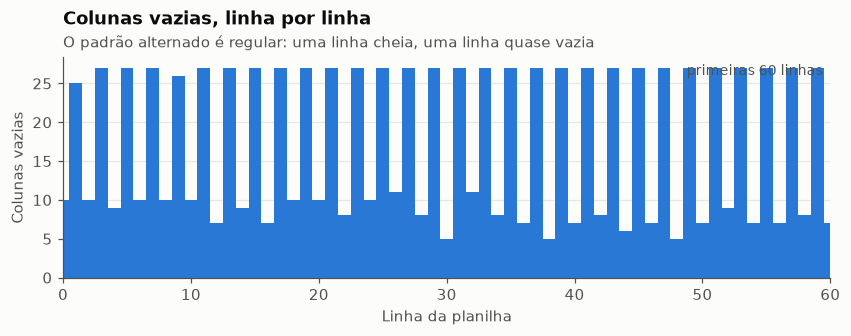

In [3]:
vazios_por_linha = cru.isna().sum(axis=1)
total_colunas = cru.shape[1]

print(f"Linhas totais                       : {len(cru)}")
print(f"Linhas com MAIS DE 90% das colunas vazias: "
      f"{(vazios_por_linha > 0.9 * total_colunas).sum()}")
print(f"Linhas com a coluna ID preenchida   : {cru['ID'].notna().sum()}")

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.bar(range(len(cru)), vazios_por_linha, width=1.0, color=AZUL, linewidth=0)
rotule(ax, "Colunas vazias, linha por linha",
       "O padrão alternado é regular: uma linha cheia, uma linha quase vazia",
       xlab="Linha da planilha", ylab="Colunas vazias")
so_y(ax)
ax.set_xlim(0, 60)
ax.text(0.99, 0.92, "primeiras 60 linhas", transform=ax.transAxes,
        ha="right", fontsize=9, color=TINTA2)
plt.show()

O serrote é perfeitamente regular. Isso não é sujeira aleatória — é **estrutura**.
A planilha foi preenchida à mão durante o evento, e alguém reservou duas linhas por
paciente. O `read_excel` está lendo certo; nós estamos lendo errado.

---
## 2. Como a planilha está montada de verdade?

Para ver o que o pandas esconde, é preciso descer ao `openpyxl` e olhar as células
mescladas.

In [4]:
wb = openpyxl.load_workbook(PLANILHA, data_only=True)
print("Abas:", wb.sheetnames)

for nome in wb.sheetnames:
    aba = wb[nome]
    faixas = list(aba.merged_cells.ranges)
    alturas = Counter(f.max_row - f.min_row + 1 for f in faixas)
    print(f"\n{nome}: {aba.max_row} linhas, {aba.max_column} colunas")
    print(f"  células mescladas: {len(faixas)}")
    print(f"  altura das mesclagens: {dict(alturas)}")

Abas: ['60+', '60-']

60+: 333 linhas, 27 colunas
  células mescladas: 3839
  altura das mesclagens: {2: 3839}

60-: 232 linhas, 27 colunas
  células mescladas: 2769
  altura das mesclagens: {2: 2769}


**3.839 mesclagens na aba 60+, todas com exatamente duas linhas de altura.** Está
confirmado: cada paciente ocupa um bloco de 2 linhas.

Falta saber onde o dado realmente mora dentro do bloco. Vamos olhar o paciente 1 em
cru, célula por célula.

In [5]:
aba = wb["60+"]
cabecalhos = [re.sub(r"\s+", " ", str(aba.cell(1, c).value)).strip()
              for c in range(1, aba.max_column + 1)]

comparacao = pd.DataFrame({
    "coluna": cabecalhos,
    "linha 2 (1ª do bloco)": [aba.cell(2, c).value for c in range(1, 28)],
    "linha 3 (2ª do bloco)": [aba.cell(3, c).value for c in range(1, 28)],
})
comparacao

,coluna,linha 2 (1ª do bloco),linha 3 (2ª do bloco)
0,ID,1,NaN
1,Sexo,None,M
2,Idade,68,NaN
3,Clínica/Dx,LEA,NaN
4,Diagnóstico Funcional,None,Hemiparesia
5,Polifarmácia?,None,NaN
6,Suporte social (terapêutico),Esposa e filhos,NaN
7,Suporte social (domiciliar),Esposa e filhos,NaN
8,Status funcional,Marcha domiciliar com supervisão,NaN
9,Cognição (MOCA),None,NaN


Aqui está a pegadinha que faz a diferença: **`Sexo` está vazio na primeira linha e
tem `M` na segunda.** O mesmo com `Diagnóstico Funcional` (`Hemiparesia`).

Onde a célula foi mesclada, o valor fica na primeira linha. Onde **não** foi
mesclada, quem preencheu digitou na linha de baixo. Se pegarmos só as linhas ímpares
perdemos esses valores em silêncio — e sexo é variável de análise.

A regra segura é: **tomar o primeiro valor não-vazio do par.** Antes de confiar
nisso, vamos provar que as duas linhas nunca se contradizem.

In [6]:
def normaliza(valor):
    '''Colapsa espaços e devolve None para vazio. Não altera conteúdo.'''
    if valor is None:
        return None
    if isinstance(valor, str):
        texto = re.sub(r"\s+", " ", valor).strip()
        return texto or None
    return valor


conflitos = []
for nome in wb.sheetnames:
    aba_ = wb[nome]
    for linha in range(2, aba_.max_row + 1, 2):
        for c, cab in enumerate(cabecalhos, start=1):
            a = normaliza(aba_.cell(linha, c).value)
            b = normaliza(aba_.cell(linha + 1, c).value) if linha + 1 <= aba_.max_row else None
            if a is not None and b is not None and str(a) != str(b):
                conflitos.append((nome, linha, cab, a, b))

print(f"Pares em que as duas linhas discordam: {len(conflitos)}")
print("-> Nenhum conflito: o primeiro valor não-vazio do par é seguro.")

Pares em que as duas linhas discordam: 0
-> Nenhum conflito: o primeiro valor não-vazio do par é seguro.


Zero conflitos nos 282 blocos. Podemos achatar com segurança.

In [7]:
def achata(nome_aba):
    '''Devolve um DataFrame com uma linha por paciente, valores como digitados.'''
    aba_ = wb[nome_aba]
    cabs = [re.sub(r"\s+", " ", str(aba_.cell(1, c).value)).strip()
            for c in range(1, aba_.max_column + 1)]
    registros = []
    for linha in range(2, aba_.max_row + 1, 2):
        reg = OrderedDict()
        for c, cab in enumerate(cabs, start=1):
            primeira = normaliza(aba_.cell(linha, c).value)
            segunda = (normaliza(aba_.cell(linha + 1, c).value)
                       if linha + 1 <= aba_.max_row else None)
            reg[cab] = primeira if primeira is not None else segunda
        reg["aba"] = nome_aba
        registros.append(reg)
    return pd.DataFrame(registros)


mais = achata("60+")
menos = achata("60-")
print(f"60+ : {mais.shape[0]} pacientes")
print(f"60- : {menos.shape[0]} pacientes")
print(f"total: {mais.shape[0] + menos.shape[0]} (o enunciado falava de ~280)")
mais.head()

60+ : 166 pacientes
60- : 116 pacientes
total: 282 (o enunciado falava de ~280)


,ID,Sexo,Idade,Clínica/Dx,Diagnóstico Funcional,Polifarmácia?,Suporte social (terapêutico),Suporte social (domiciliar),Status funcional,Cognição (MOCA),Cognição (10-CS),Nº quedas ao chão,Queda último mês,Sentar/levantar 30s,Ponte,Dinamômetro,Panturrilha D,Panturrilha E,Braço D,Braço E,10 metros,Aditamento 10m,CIF equilíbrio,Posição equilíbrio,Reação (blazepod),Reação (blazepod) DT,Custo dupla tarefa,aba
0,1,M,68,LEA,Hemiparesia,NaN,Esposa e filhos,Esposa e filhos,Marcha domiciliar com supervisão,NaN,NaN,4,sim,None,14,28,33,35,NaN,None,53,Bastão de caminhada,0,Sentado,11.0,NA,None,60+
1,2,M,72,AMP,NaN,NaN,amigo,NaN,NaN,20.0,NaN,0,não,None,16,36,36,NA,NaN,None,10,Muletas axilares,0,Sentado,40.0,18,None,60+
2,3,F,77,Parkison,NaN,não,cuidadora,marido,NaN,20.0,7.0,0,não,None,28,19,NA,37,NaN,None,NA,NaN,0,Sentado,39.0,31,None,60+
3,4,M,62,AMP,NaN,NaN,.,.,NaN,NaN,NaN,1,sim,9,None,33,41,NA,NaN,None,7,Muleta canadense unilateral,0,Ortostatismo,33.0,19,None,60+
4,5,F,62,DNM,NaN,NaN,.,.,Deambuladora comunitária independente,NaN,NaN,2,não,None,10,NA,33.5,32,NaN,None,7,nenhum,0,Ortostatismo,33.0,19,None,60+


166 e 116. Bate com o "cerca de 280 pacientes" do enunciado.

Última verificação de integridade antes de seguir: os IDs.

In [8]:
for nome, df in [("60+", mais), ("60-", menos)]:
    ids = df["ID"]
    print(f"{nome}: {ids.min()}–{ids.max()} | "
          f"duplicados: {ids.duplicated().sum()} | "
          f"faltando na sequência: {sorted(set(range(int(ids.min()), int(ids.max()) + 1)) - set(ids.astype(int)))}")

60+: 1–166 | duplicados: 0 | faltando na sequência: []
60-: 1–116 | duplicados: 0 | faltando na sequência: []


**O que aprendemos na seção 2.** A estrutura de 2 linhas é a barreira de entrada da
base. Quem não tratar isso vai analisar 332 pacientes fantasma, ou vai perder o sexo
de parte da amostra sem perceber. `sexo` sozinho já justifica o cuidado.

---
## 3. As colunas têm tipo?

Agora temos uma linha por paciente. A tentação é partir para o `describe()`. Vamos
fazer isso e ver no que dá.

In [9]:
mais[["Idade", "Dinamômetro", "Panturrilha D", "10 metros", "CIF equilíbrio"]].describe()

,Idade,Dinamômetro,Panturrilha D,10 metros,CIF equilíbrio
count,166,162,150,163,163
unique,33,41,33,76,6
top,64,22,NA,NA,0
freq,16,13,52,32,89


`describe()` devolve estatística só de parte das colunas, e para `Panturrilha D` e
`10 metros` ele nem tenta — elas voltaram como `object`. O motivo: **cada coluna
tem mais de um tipo de Python dentro.**

Vamos fazer o censo de tipos.

In [10]:
def censo_tipos(df):
    linhas = []
    for col in df.columns:
        if col == "aba":
            continue
        preenchidos = df[col].dropna()
        tipos = Counter(type(v).__name__ for v in preenchidos)
        # Textos que não são número: os marcadores escritos à mão.
        marcadores = Counter(
            str(v) for v in preenchidos
            if isinstance(v, str) and not re.fullmatch(r"-?\d+([.,]\d+)?", str(v).strip())
        )
        linhas.append({
            "coluna": col,
            "preenchidos": len(preenchidos),
            "vazios": df[col].isna().sum(),
            "tipos": dict(tipos),
            "nº de tipos": len(tipos),
            "marcadores de texto": dict(marcadores.most_common(3)),
        })
    return pd.DataFrame(linhas)


censo = censo_tipos(mais)
censo.sort_values("nº de tipos", ascending=False).head(14)

,coluna,preenchidos,vazios,tipos,nº de tipos,marcadores de texto
15,Dinamômetro,162,4,"{'int': 159, 'str': 1, 'float': 2}",3,{'NA': 1}
17,Panturrilha E,149,17,"{'int': 66, 'str': 57, 'float': 26}",3,{'NA': 57}
16,Panturrilha D,150,16,"{'int': 64, 'str': 54, 'float': 32}",3,"{'NA': 52, 'AMP': 2}"
19,Braço E,11,155,"{'int': 8, 'float': 2, 'str': 1}",3,{'NA': 1}
20,10 metros,163,3,"{'int': 117, 'str': 32, 'float': 14}",3,{'NA': 32}
13,Sentar/levantar 30s,51,115,"{'int': 47, 'str': 4}",2,{'NA': 4}
14,Ponte,113,53,"{'int': 112, 'str': 1}",2,{'NA': 1}
11,Nº quedas ao chão,161,5,"{'int': 160, 'str': 1}",2,{'´2': 1}
2,Idade,166,0,"{'int': 160, 'str': 6}",2,"{'59?': 4, '57?': 2}"
12,Queda último mês,161,5,"{'str': 153, 'int': 8}",2,"{'não': 117, 'sim': 36}"


Aí está o problema, explícito:

- **`Panturrilha D`** tem `int`, `str` **e** `float` na mesma coluna — 3 tipos.
- O `str` não é lixo: é **`NA` escrito à mão** para "teste não realizado", e
  **`AMP`** em dois pacientes, para dizer que o membro foi amputado.
- **`Queda último mês`** mistura `'sim'`/`'não'` com os números `0` e `2`.
- **`Idade`** tem 6 valores como `'59?'` — o avaliador anotou a dúvida junto.

Nenhuma coluna está tipada. Isso não é detalhe cosmético: com `object`, `.mean()`
falha ou ignora silenciosamente metade da amostra, e `.corr()` simplesmente descarta
a coluna.

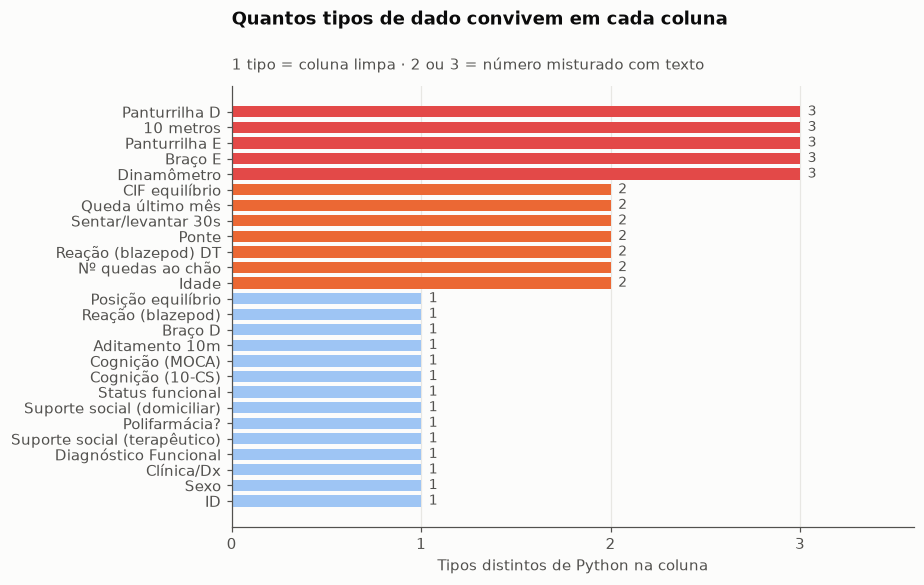

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.2))
alvo = censo[censo["nº de tipos"] > 0].sort_values("nº de tipos")
cores = [AZUIS[1] if n == 1 else (LARANJA if n == 2 else VERMELHO)
         for n in alvo["nº de tipos"]]
barras = ax.barh(alvo["coluna"], alvo["nº de tipos"], color=cores, height=0.72)
for b, n in zip(barras, alvo["nº de tipos"]):
    ax.text(b.get_width() + 0.04, b.get_y() + b.get_height() / 2, str(n),
            va="center", fontsize=9, color=TINTA2)
rotule(ax, "Quantos tipos de dado convivem em cada coluna",
       "1 tipo = coluna limpa · 2 ou 3 = número misturado com texto",
       xlab="Tipos distintos de Python na coluna")
so_x(ax)
ax.set_xlim(0, 3.6)
ax.set_xticks([0, 1, 2, 3])
plt.show()

**O que aprendemos na seção 3.** Nenhuma coluna numérica está utilizável como está.
A tipagem não é etapa opcional de arrumação — é o que separa uma média correta de
uma média calculada sobre metade dos pacientes.

---
## 4. Como tipar sem inventar dado?

Aqui entra a regra do projeto: *"Não corrijam dados por suposição: na dúvida,
perguntem à AACD."*

Então a conversão precisa distinguir três situações que o `NaN` do pandas trata
igual:

| Situação | Exemplo | Como tratar |
|---|---|---|
| **Não aplicável** | panturrilha de quem tem amputação | ausente **estrutural** — nunca imputar |
| **Não realizado** | `NA` escrito à mão no teste de 10 m | ausente por protocolo — marcar |
| **Não informado** | célula em branco em polifarmácia | ausente de verdade |

Vamos usar os tipos *nullable* do pandas (`Int64`, `Float64`, `boolean`), que
guardam nulo sem virar `float` nem perder a informação de tipo.

In [12]:
# Marcadores escritos à mão. 'NA' foi usado para "não realizado"; 'AMP' aparece
# em panturrilha e significa membro amputado — ausência estrutural.
NAO_REALIZADO = {"NA", "N/A", "na", "n/a"}
NAO_APLICAVEL = {"AMP"}
# Valores que não sabemos o que são; ficam nulos e vão para as pendências.
DUVIDOSOS = {".", "-", "?", "k", "o"}


def para_numero(valor):
    '''Converte para float quando é número de fato; senão devolve (None, motivo).

    Tolera vírgula decimal e o apóstrofo que o Excel deixa na frente ('´2).
    Um '?' no fim é dúvida do avaliador: aproveitamos o número e marcamos o caso.
    '''
    if valor is None or (isinstance(valor, float) and pd.isna(valor)):
        return None, "nao_informado"
    if isinstance(valor, (int, float)):
        return float(valor), None
    texto = str(valor).strip()
    if texto in NAO_REALIZADO:
        return None, "nao_realizado"
    if texto in NAO_APLICAVEL:
        return None, "nao_aplicavel"
    if texto in DUVIDOSOS:
        return None, "duvidoso"
    limpo = texto.replace(",", ".").lstrip("´`'").rstrip("?")
    try:
        return float(limpo), ("valor_com_duvida" if texto.endswith("?") else None)
    except ValueError:
        return None, "nao_numerico"


# Teste rápido da função, com os casos reais que existem na base.
for amostra in ["33.5", "NA", "AMP", "59?", "´2", ".", "k", 28, None]:
    print(f"  {amostra!s:>6} -> {para_numero(amostra)}")

    33.5 -> (33.5, None)
      NA -> (None, 'nao_realizado')
     AMP -> (None, 'nao_aplicavel')
     59? -> (59.0, 'valor_com_duvida')
      ´2 -> (2.0, None)
       . -> (None, 'duvidoso')
       k -> (None, 'duvidoso')
      28 -> (28.0, None)
    None -> (None, 'nao_informado')


In [13]:
# Mapa: coluna original -> (nome novo, tipo alvo, domínio plausível)
NUMERICAS = {
    "Idade":                 ("idade",            "Int64",   (18, 110)),
    "Cognição (MOCA)":       ("moca",             "Int64",   (0, 30)),
    "Cognição (10-CS)":      ("dez_cs",           "Int64",   (0, 10)),
    "Nº quedas ao chão":     ("n_quedas",         "Int64",   (0, 60)),
    "Sentar/levantar 30s":   ("sentar_levantar",  "Int64",   (0, 40)),
    "Ponte":                 ("ponte",            "Int64",   (0, 120)),
    "Dinamômetro":           ("dinamometro",      "Float64", (0, 90)),
    "Panturrilha D":         ("panturrilha_d",    "Float64", (15, 65)),
    "Panturrilha E":         ("panturrilha_e",    "Float64", (15, 65)),
    "Braço D":               ("braco_d",          "Float64", (15, 60)),
    "Braço E":               ("braco_e",          "Float64", (15, 60)),
    "10 metros":             ("tempo_10m",        "Float64", (3, 400)),
    "CIF equilíbrio":        ("cif_equilibrio",   "Int64",   (0, 4)),
    "Reação (blazepod)":     ("reacao",           "Int64",   (0, 120)),
    "Reação (blazepod) DT":  ("reacao_dt",        "Int64",   (0, 120)),
}


def tipa_numericas(df):
    '''Converte as colunas numéricas e devolve (df tipado, avisos de domínio).'''
    saida = pd.DataFrame(index=df.index)
    avisos = []
    for original, (novo, tipo, (piso, teto)) in NUMERICAS.items():
        valores, motivos = [], []
        for idx, bruto in df[original].items():
            num, motivo = para_numero(bruto)
            valores.append(num)
            motivos.append(motivo)
            if num is not None and not (piso <= num <= teto):
                avisos.append({"id": df.at[idx, "ID"], "aba": df.at[idx, "aba"],
                               "campo": novo, "valor": num,
                               "dominio": f"{piso}–{teto}"})
            if motivo in ("duvidoso", "nao_numerico", "valor_com_duvida"):
                avisos.append({"id": df.at[idx, "ID"], "aba": df.at[idx, "aba"],
                               "campo": novo, "valor": bruto, "dominio": motivo})
        saida[novo] = pd.array(valores, dtype=tipo)
        # Guarda POR QUE está vazio, só onde a distinção muda a análise.
        if novo in ("panturrilha_d", "panturrilha_e", "tempo_10m", "ponte",
                    "sentar_levantar", "reacao", "reacao_dt", "dinamometro"):
            saida[f"{novo}_motivo_ausencia"] = motivos
    return saida, pd.DataFrame(avisos)


num_mais, avisos_mais = tipa_numericas(mais)
num_menos, avisos_menos = tipa_numericas(menos)

print("Tipos depois da conversão:")
print(num_mais[[v[0] for v in NUMERICAS.values()]].dtypes.to_string())

Tipos depois da conversão:
idade                Int64
moca                 Int64
dez_cs               Int64
n_quedas             Int64
sentar_levantar      Int64
ponte                Int64
dinamometro        Float64
panturrilha_d      Float64
panturrilha_e      Float64
braco_d            Float64
braco_e            Float64
tempo_10m          Float64
cif_equilibrio       Int64
reacao               Int64
reacao_dt            Int64


Agora sim: `Int64` e `Float64` de verdade, com nulo preservado. O `describe()` passa
a funcionar em todas.

In [14]:
num_mais[["idade", "dinamometro", "panturrilha_d", "tempo_10m", "reacao"]].describe().round(2)

,idade,dinamometro,panturrilha_d,tempo_10m,reacao
count,166.0,161.0,96.0,131.0,163.0
mean,68.85,25.99,35.21,34.64,30.08
std,7.38,9.18,3.87,31.54,9.13
min,57.0,0.0,22.5,1.2,4.0
25%,63.25,19.0,33.0,13.12,23.5
50%,67.0,25.0,35.25,27.0,31.0
75%,73.0,32.0,37.5,44.5,37.0
max,91.0,51.0,47.0,201.0,48.0


### O que a validação de domínio encontrou

Ao converter, checamos se cada valor cabe no intervalo plausível do instrumento.
Isso pega erros que passariam batido.

In [15]:
avisos = pd.concat([avisos_mais, avisos_menos], ignore_index=True)
avisos.sort_values(["campo", "id"])

,id,aba,campo,valor,dominio
10,18,60-,braco_d,13.0,15–60
11,45,60-,cif_equilibrio,o,duvidoso
6,113,60+,dez_cs,11.0,0–10
7,115,60+,dez_cs,12.0,0–10
0,21,60+,idade,57?,valor_com_duvida
1,41,60+,idade,59?,valor_com_duvida
2,42,60+,idade,57?,valor_com_duvida
3,75,60+,idade,59?,valor_com_duvida
4,88,60+,idade,59?,valor_com_duvida
9,109,60-,idade,k,duvidoso


Três achados que só a validação de domínio revela:

1. **`dez_cs` com 11 e 12.** O 10-CS é um instrumento de **0 a 10 pontos** — o nome
   diz. Valores acima de 10 são impossíveis e precisam ser confirmados com a AACD.
2. **`tempo_10m` = 1,2 s.** Dez metros em 1,2 s são 8,3 m/s — velocidade de
   velocista olímpico, num paciente cadeirante. É erro de digitação.
3. **`idade` com `'59?'` e `'k'`.** O `'k'` é tecla batida sem querer; os `'59?'`
   são idosos de 59 anos na aba dos 60+.

Nenhum desses é corrigido aqui. Todos vão para a tabela de pendências.

---
## 5. Quantas formas de escrever "andador" existem?

As colunas numéricas estão resolvidas. As de texto são o outro problema — e maior.

In [16]:
texto = ["Sexo", "Clínica/Dx", "Diagnóstico Funcional", "Polifarmácia?",
         "Suporte social (terapêutico)", "Suporte social (domiciliar)",
         "Status funcional", "Aditamento 10m", "Posição equilíbrio",
         "Queda último mês"]
juntas = pd.concat([mais, menos], ignore_index=True)

resumo = pd.DataFrame({
    "coluna": texto,
    "preenchidos": [juntas[c].notna().sum() for c in texto],
    "valores distintos": [juntas[c].nunique() for c in texto],
})
resumo["distintos / preenchidos"] = (
    resumo["valores distintos"] / resumo["preenchidos"]).round(3)
resumo.sort_values("valores distintos", ascending=False)

,coluna,preenchidos,valores distintos,distintos / preenchidos
6,Status funcional,264,128,0.485
5,Suporte social (domiciliar),264,79,0.299
4,Suporte social (terapêutico),277,62,0.224
7,Aditamento 10m,230,25,0.109
1,Clínica/Dx,282,18,0.064
2,Diagnóstico Funcional,68,14,0.206
8,Posição equilíbrio,277,5,0.018
9,Queda último mês,275,4,0.015
0,Sexo,282,2,0.007
3,Polifarmácia?,249,2,0.008


**`Status funcional`: 128 valores distintos para 264 preenchimentos.** É texto livre
puro — quase um valor novo a cada dois pacientes. `Suporte social (domiciliar)` tem
79. Sem padronizar, nenhum agrupamento funciona.

Vamos ver de perto os diagnósticos, que são a coluna mais curta.

In [17]:
juntas["Clínica/Dx"].value_counts().to_frame("pacientes")

,pacientes
Clínica/Dx,
AMP,104
LEA,75
LM,22
PC,17
DNM,12
Polio,11
MFC,9
Parkison,7
Parkinson,6


`Parkison` (7) e `Parkinson` (6) são a **mesma doença contada duas vezes**. Juntando,
Parkinson passa de 7º para o 5º diagnóstico mais comum — muda a descrição da
população.

E o aditamento:

In [18]:
juntas["Aditamento 10m"].value_counts().to_frame("pacientes")

,pacientes
Aditamento 10m,
Andador reciprocado,61
nenhum,41
Muletas canadenses,26
Cadeira de rodas,18
Muleta canadense unilateral,14
Bengala simples,14
Muletas axilares,11
Bengala de 4 apoios,8
Nenhum,6


`Bengala de 4 apoios` / `Bengala 4 apoios`. `Andador com rodas dianteras` (com erro
de digitação) / `Andador de rodas dianteiras` / `Andador rodas dianteiras`.
`Cadeira` / `Cadeira de rodas` / `Cadeira?`. São 25 rótulos para cerca de 5 grupos
reais.

A padronização vai num **dicionário explícito e versionado** — nunca em regex solta
espalhada pelo código. Assim a decisão fica auditável e a AACD pode revisar.

In [19]:
# Cada chave é um grupo clínico; a lista traz os padrões que caem nele.
# A ordem importa: 'cadeira' antes de 'andador' porque há registros com os dois.
GRUPOS_ADITAMENTO = [
    ("nenhum",           [r"^nenhum"]),
    ("cadeira de rodas", [r"cadeira"]),
    ("andador",          [r"andador"]),
    ("muleta",           [r"muleta"]),
    ("bengala",          [r"bengala"]),
    ("bastão",           [r"bast[ãa]o"]),
]

GRUPOS_DX = {
    "Parkinson": [r"parkin?son"],       # cobre 'Parkison'
    "AMP":       [r"^amp"],             # inclui 'AMP bilateral', 'AMP/LEA'
    "LEA":       [r"^lea"],
    "LM":        [r"^lm", r"^mielo"],
    "DNM":       [r"^dnm", r"^ela"],    # ELA é uma doença do neurônio motor
    "PC":        [r"^pc"],
    "Polio":     [r"^polio"],
    "MFC":       [r"^mfc"],
    "EM":        [r"^em$"],
    "AVC":       [r"^avc"],
    "Tumor":     [r"tumor"],
}


def classifica(valor, grupos, padrao="outro"):
    '''Devolve o grupo do primeiro padrão que casar. Ordem = prioridade.'''
    if valor is None or pd.isna(valor):
        return None
    texto_ = str(valor).lower()
    itens = grupos.items() if isinstance(grupos, dict) else grupos
    for grupo, padroes in itens:
        if any(re.search(p, texto_) for p in padroes):
            return grupo
    return padrao


for df in (mais, menos):
    df["dx_grupo"] = df["Clínica/Dx"].apply(lambda v: classifica(v, GRUPOS_DX))
    df["aditamento_grupo"] = df["Aditamento 10m"].apply(
        lambda v: classifica(v, GRUPOS_ADITAMENTO))

antes = juntas["Clínica/Dx"].nunique()
depois = pd.concat([mais, menos], ignore_index=True)["dx_grupo"].nunique()
print(f"Clínica/Dx      : {antes} rótulos -> {depois} grupos")
print(f"Aditamento 10m  : {juntas['Aditamento 10m'].nunique()} rótulos -> "
      f"{pd.concat([mais, menos], ignore_index=True)['aditamento_grupo'].nunique()} grupos")

Clínica/Dx      : 18 rótulos -> 11 grupos
Aditamento 10m  : 25 rótulos -> 6 grupos


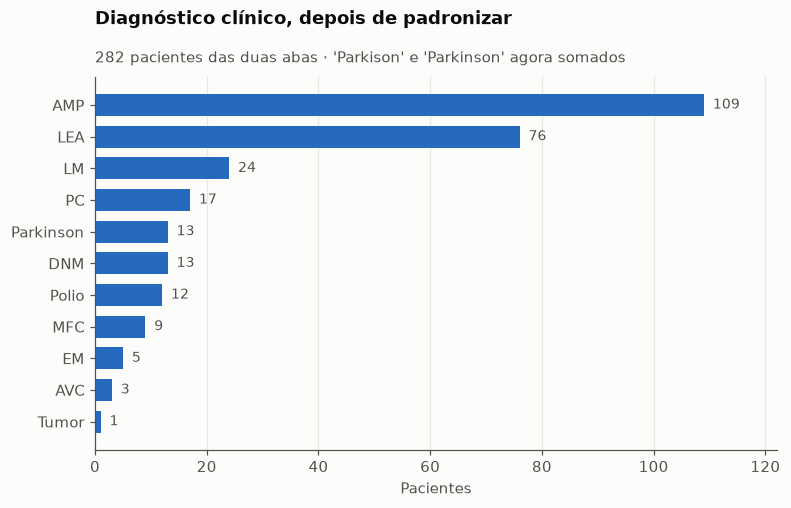

In [20]:
todos = pd.concat([mais, menos], ignore_index=True)
contagem = todos["dx_grupo"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4.4))
barras = ax.barh(contagem.index[::-1], contagem.values[::-1],
                 color=AZUIS[4], height=0.7)
for b, v in zip(barras, contagem.values[::-1]):
    ax.text(b.get_width() + 1.6, b.get_y() + b.get_height() / 2, str(v),
            va="center", fontsize=9, color=TINTA2)
rotule(ax, "Diagnóstico clínico, depois de padronizar",
       f"{len(todos)} pacientes das duas abas · 'Parkison' e 'Parkinson' agora somados",
       xlab="Pacientes")
so_x(ax)
ax.set_xlim(0, contagem.max() * 1.12)
plt.show()

### `Status funcional`: dois eixos escondidos num campo

Este campo é o mais rico e o mais desarrumado. Lendo os 128 valores, percebe-se que
ele guarda **duas informações diferentes** no mesmo texto:

- **até onde a pessoa se locomove** — terapêutica (só na sessão), domiciliar
  (dentro de casa), comunitária (na rua);
- **se precisa de supervisão** de outra pessoa.

E há um terceiro detalhe que importa muito: registros como
`Cadeirante longas distâncias e Andador domiciliar` ou
`Marcha domiciliar com andador / maior parte do tempo cadeirante (90%)` mostram que
**mobilidade não é binária.** Quem anda em casa mas usa cadeira na rua não é nem
"cadeirante" nem "deambulador". Vamos guardar esse caso à parte — a seção 8 mostra
por que ele é decisivo.

In [21]:
NIVEIS_MARCHA = [
    ("comunitária", [r"comunit", r"deambulador?a? comunit", r"marca comunit",
                     r"marhca comunit", r"deambula independente", r"marcha independente"]),
    ("domiciliar",  [r"domicil", r"domicli"]),
    ("terapêutica", [r"terap"]),
]


def nivel_marcha(valor):
    '''Maior alcance de marcha mencionado. Cadeira pura vira 'cadeira de rodas'.'''
    if valor is None or pd.isna(valor):
        return None
    t = str(valor).lower()
    for nivel, padroes in NIVEIS_MARCHA:
        if any(re.search(p, t) for p in padroes):
            return nivel
    if re.search(r"cadeir|\bcr\b", t):
        return "cadeira de rodas"
    if re.search(r"marcha|deambula", t):
        return "marcha sem alcance especificado"
    return "outro"


def perfil_mobilidade(valor):
    '''Separa quem só usa cadeira de quem combina cadeira e marcha.'''
    if valor is None or pd.isna(valor):
        return None
    t = str(valor).lower()
    tem_cadeira = bool(re.search(r"cadeir|\bcr\b", t))
    tem_marcha = bool(re.search(r"marcha|deambula|andador|muleta|bengala|bast", t))
    if tem_cadeira and tem_marcha:
        return "misto (anda e usa cadeira)"
    if tem_cadeira:
        return "só cadeira de rodas"
    if tem_marcha:
        return "anda"
    return None


def precisa_supervisao(valor):
    if valor is None or pd.isna(valor):
        return pd.NA
    t = str(valor).lower()
    if re.search(r"sem supervis", t):
        return False
    if re.search(r"supervis|apoio (de|em) terceiros|condutor|tocado por terceiros", t):
        return True
    return pd.NA


for df in (mais, menos):
    df["nivel_marcha"] = df["Status funcional"].apply(nivel_marcha)
    df["perfil_mobilidade"] = df["Status funcional"].apply(perfil_mobilidade)
    df["supervisao"] = df["Status funcional"].apply(precisa_supervisao).astype("boolean")

pd.crosstab(pd.concat([mais, menos], ignore_index=True)["perfil_mobilidade"],
            pd.concat([mais, menos], ignore_index=True)["aba"], margins=True, margins_name="total")

aba,60+,60-,total
perfil_mobilidade,,,
anda,101,91,192
misto (anda e usa cadeira),6,0,6
só cadeira de rodas,43,22,65
total,150,113,263


### Suporte social: `Independente` e `sozinha` não são a mesma coisa

Cuidado fácil de errar. No campo domiciliar aparece um `sozinha` e alguns
`Funcionários ILPI` / `Cuidadora do residencial`. Colapsar tudo em "independente"
apagaria duas situações de risco bem diferentes: morar só e morar em instituição.

In [22]:
GRUPOS_SUPORTE = [
    ("mora só",         [r"^sozinh"]),
    ("institucional",   [r"ilpi", r"residencial", r"programa de acompanhante"]),
    ("independente",    [r"independe", r"independet"]),   # cobre 'Independete'
    ("cônjuge",         [r"espo", r"marido", r"noiv", r"namorad"]),
    ("filho(a)",        [r"filh"]),
    ("cuidador(a)",     [r"cuidador"]),
    ("pai/mãe",         [r"^m[ãa]e", r"^pai", r"\bpais\b"]),
    ("outro familiar",  [r"irm", r"imr", r"neto", r"neta", r"sobrinh", r"av[óo]",
                         r"genro", r"nora", r"tia", r"primo", r"enteada", r"padrasto"]),
    ("não familiar",    [r"amig", r"vizinh"]),
    ("outra pessoa",    [r"outra pessoa"]),
]

for df in (mais, menos):
    for origem, destino in [("Suporte social (terapêutico)", "suporte_terapeutico"),
                            ("Suporte social (domiciliar)", "suporte_domiciliar")]:
        df[destino] = df[origem].apply(
            lambda v: None if (v is None or str(v) == ".")
            else classifica(v, GRUPOS_SUPORTE, padrao="não classificado"))

vis = pd.concat([mais, menos], ignore_index=True)["suporte_domiciliar"].value_counts()
print(vis.to_string())
print(f"\n'.' tratado como nulo (significado a confirmar com a AACD): "
      f"{(pd.concat([mais, menos], ignore_index=True)['Suporte social (domiciliar)'] == '.').sum()} pacientes")

suporte_domiciliar
cônjuge           105
filho(a)           42
pai/mãe            39
independente       35
cuidador(a)        15
outro familiar     15
outra pessoa        4
não familiar        3
institucional       2
mora só             1

'.' tratado como nulo (significado a confirmar com a AACD): 3 pacientes


### Booleanos

`Polifarmácia?` e `Queda último mês` são sim/não — exceto onde não são. Oito
pacientes têm `Queda último mês` gravado como número (`0` e `2`), e são os **IDs
22 a 29, consecutivos**. Isso não é aleatório: é um avaliador, ou uma estação de
coleta, usando convenção própria.

Interpretar `0` como "não caiu" é razoável, mas **é uma interpretação**. Então
convertemos *e marcamos*, para ficar auditável e reversível.

In [23]:
def para_booleano(valor):
    ''''sim'/'não' -> True/False. Número -> interpretado e sinalizado.'''
    if valor is None or (isinstance(valor, float) and pd.isna(valor)):
        return pd.NA, False
    if isinstance(valor, str):
        t = valor.strip().lower()
        if t in ("sim", "s"):
            return True, False
        if t in ("não", "nao", "n"):
            return False, False
        return pd.NA, False
    if isinstance(valor, (int, float)):
        return bool(valor >= 1), True     # 0 -> não caiu; >=1 -> caiu
    return pd.NA, False


for df in (mais, menos):
    for origem, destino in [("Polifarmácia?", "polifarmacia"),
                            ("Queda último mês", "queda_ultimo_mes")]:
        pares = df[origem].apply(para_booleano)
        df[destino] = pd.array([p[0] for p in pares], dtype="boolean")
        df[f"{destino}_reinterpretado"] = [p[1] for p in pares]

marcados = mais[mais["queda_ultimo_mes_reinterpretado"]]
print(f"Reinterpretados em 'queda_ultimo_mes' (aba 60+): {len(marcados)}")
print("IDs:", marcados["ID"].tolist())
print("\nConferência: o valor numérico bate com o nº de quedas no ano?")
marcados[["ID", "Queda último mês", "Nº quedas ao chão", "queda_ultimo_mes"]]

Reinterpretados em 'queda_ultimo_mes' (aba 60+): 8
IDs: [22, 23, 24, 25, 26, 27, 28, 29]

Conferência: o valor numérico bate com o nº de quedas no ano?


,ID,Queda último mês,Nº quedas ao chão,queda_ultimo_mes
21,22,0,0,False
22,23,0,0,False
23,24,2,3,True
24,25,0,0,False
25,26,0,0,False
26,27,0,0,False
27,28,0,1,False
28,29,0,0,False


**O que aprendemos na seção 5.** O texto livre esconde mais informação do que os
números: dois eixos dentro de `Status funcional`, a diferença entre morar só e ser
independente, e um efeito de lote nos IDs 22–29 que só aparece quando se olha *quem*
preencheu. Padronizar em dicionário versionado mantém tudo isso auditável.

---
## 6. Todo vazio é vazio?

Vamos montar a base final tipada e olhar as lacunas.

In [24]:
def monta_base(df_bruto, df_num):
    '''Junta as colunas tipadas, as categóricas padronizadas e as derivadas.'''
    base = pd.concat([
        df_bruto[["ID", "aba"]].reset_index(drop=True),
        df_num.reset_index(drop=True),
    ], axis=1)
    categoricas = ["dx_grupo", "aditamento_grupo", "nivel_marcha", "perfil_mobilidade",
                   "suporte_terapeutico", "suporte_domiciliar"]
    for col in categoricas:
        base[col] = pd.Categorical(df_bruto[col].reset_index(drop=True))
    for col in ["polifarmacia", "queda_ultimo_mes", "supervisao",
                "queda_ultimo_mes_reinterpretado", "polifarmacia_reinterpretado"]:
        base[col] = df_bruto[col].reset_index(drop=True)
    base["sexo"] = pd.Categorical(df_bruto["Sexo"].reset_index(drop=True))
    # 'Sentada'/'Sentado' são o mesmo; 'NA' é ausência, não uma terceira categoria.
    pos = (df_bruto["Posição equilíbrio"].str.lower()
           .str.replace("sentada", "sentado").reset_index(drop=True))
    base["posicao_equilibrio"] = pd.Categorical(
        pos.where(~pos.isin({"na", "n/a", ".", "-", "?"})))

    # ---- derivadas ----
    base["caiu"] = (base["n_quedas"] >= 1).astype("boolean")
    base["queda_recorrente"] = (base["n_quedas"] >= 2).astype("boolean")

    # Velocidade de marcha só vale para quem percorreu os 10 m ANDANDO.
    anda = base["perfil_mobilidade"].isin(["anda", "misto (anda e usa cadeira)"])
    base["velocidade_marcha"] = (10 / base["tempo_10m"]).where(
        anda & base["tempo_10m"].notna() & (base["tempo_10m"] > 3)).round(3)

    base["custo_dupla_tarefa"] = (
        (base["reacao"] - base["reacao_dt"]) / base["reacao"] * 100
    ).where(base["reacao"] > 0).round(1)

    # Ponte e sentar/levantar são protocolos ALTERNATIVOS — ver abaixo.
    base["teste_forca_mmii"] = np.where(
        base["sentar_levantar"].notna(), "sentar/levantar",
        np.where(base["ponte"].notna(), "ponte", None))
    base["tem_forca_mmii"] = base["sentar_levantar"].notna() | base["ponte"].notna()
    return base


base_mais = monta_base(mais, num_mais)
base_menos = monta_base(menos, num_menos)
base = pd.concat([base_mais, base_menos], ignore_index=True)

print(f"Base final: {base.shape[0]} pacientes × {base.shape[1]} colunas")
base_mais.dtypes.to_frame("dtype").T

Base final: 282 pacientes × 44 colunas


,ID,aba,idade,moca,dez_cs,n_quedas,sentar_levantar,sentar_levantar_motivo_ausencia,ponte,ponte_motivo_ausencia,dinamometro,dinamometro_motivo_ausencia,panturrilha_d,panturrilha_d_motivo_ausencia,panturrilha_e,panturrilha_e_motivo_ausencia,braco_d,braco_e,tempo_10m,tempo_10m_motivo_ausencia,...,reacao_dt_motivo_ausencia,dx_grupo,aditamento_grupo,nivel_marcha,perfil_mobilidade,suporte_terapeutico,suporte_domiciliar,polifarmacia,queda_ultimo_mes,supervisao,queda_ultimo_mes_reinterpretado,polifarmacia_reinterpretado,sexo,posicao_equilibrio,caiu,queda_recorrente,velocidade_marcha,custo_dupla_tarefa,teste_forca_mmii,tem_forca_mmii
dtype,int64,str,Int64,Int64,Int64,Int64,Int64,str,Int64,str,Float64,str,Float64,str,Float64,str,Float64,Float64,Float64,str,...,str,category,category,category,category,category,category,boolean,boolean,boolean,bool,bool,category,category,boolean,boolean,Float64,Float64,str,bool


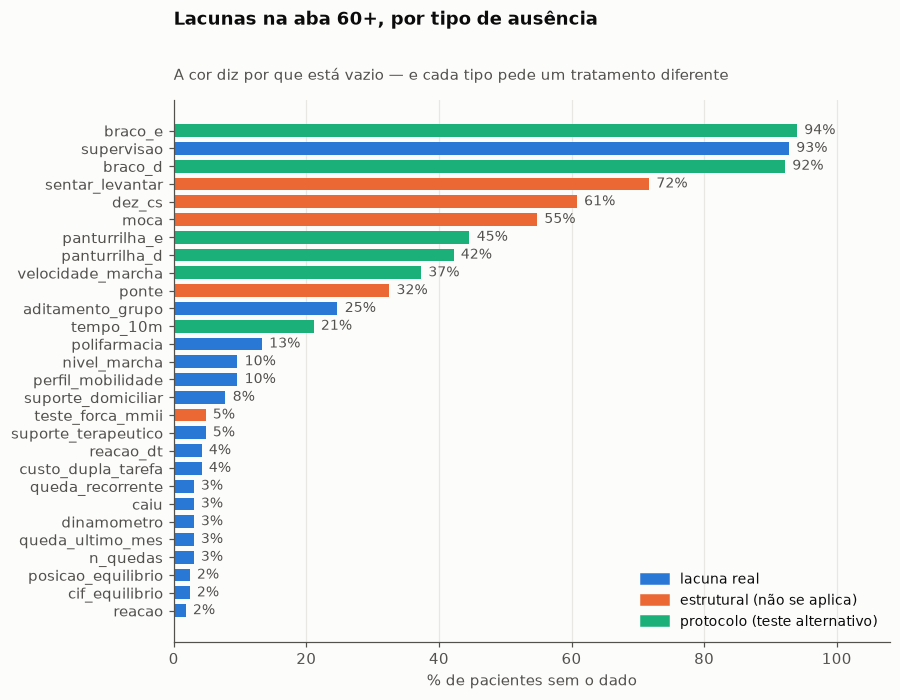

In [25]:
falta = (base_mais.isna().mean() * 100).round(1)
falta = falta[falta > 0].sort_values()
falta = falta[~falta.index.str.contains("motivo_ausencia|reinterpretado")]

# A cor diz o TIPO de ausência, não o tamanho — é informação categórica.
def tipo_ausencia(col):
    if col in ("panturrilha_d", "panturrilha_e", "braco_d", "braco_e", "tempo_10m",
               "velocidade_marcha"):
        return "estrutural (não se aplica)", AQUA
    if col in ("ponte", "sentar_levantar", "moca", "dez_cs", "teste_forca_mmii"):
        return "protocolo (teste alternativo)", LARANJA
    return "lacuna real", AZUL

tipos = [tipo_ausencia(c) for c in falta.index]

fig, ax = plt.subplots(figsize=(8.4, 6.4))
barras = ax.barh(falta.index, falta.values, color=[t[1] for t in tipos], height=0.72)
for b, v in zip(barras, falta.values):
    ax.text(b.get_width() + 1.1, b.get_y() + b.get_height() / 2, f"{v:.0f}%",
            va="center", fontsize=9, color=TINTA2)
rotule(ax, "Lacunas na aba 60+, por tipo de ausência",
       "A cor diz por que está vazio — e cada tipo pede um tratamento diferente",
       xlab="% de pacientes sem o dado")
so_x(ax)
ax.set_xlim(0, 108)
vistos, handles = set(), []
for rotulo, cor in tipos:
    if rotulo not in vistos:
        vistos.add(rotulo)
        handles.append(plt.Rectangle((0, 0), 1, 1, color=cor))
ax.legend(handles, list(vistos), loc="lower right", fontsize=9)
plt.show()

### Prova 1 — a ausência estrutural

`NA` em panturrilha não é dado perdido. Se a perna foi amputada, não há panturrilha
para medir. Imputar a média aí é **inventar uma perna**.

Nesses casos a equipe mediu a **circunferência do braço** como substituta — o
notebook 02 confirma isso nos dados. Então `braco_d`/`braco_e`, que parecem ter 92%
de lacuna, não são colunas inúteis: são a medida de recurso de quem não tem
panturrilha mensurável.

In [26]:
tab = pd.crosstab(base_mais["dx_grupo"], base_mais["panturrilha_d"].isna(),
                  normalize="index").mul(100).round(1)
tab.columns = ["medida (%)", "ausente (%)"]
tab["pacientes"] = base_mais["dx_grupo"].value_counts()
tab.sort_values("ausente (%)", ascending=False)

,medida (%),ausente (%),pacientes
dx_grupo,,,
LM,23.1,76.9,13
AMP,42.1,57.9,76
DNM,75.0,25.0,4
LEA,75.0,25.0,48
Polio,75.0,25.0,8
Parkinson,91.7,8.3,12
AVC,100.0,0.0,3
PC,100.0,0.0,1
Tumor,100.0,0.0,1


**56% dos AMP e 100% dos amputados bilaterais** sem panturrilha, contra 0% em AVC e
Parkinson. A ausência segue o diagnóstico — é estrutural, como esperado.

### Prova 2 — o protocolo alternativo

`sentar_levantar` parece ter 72% de lacuna. Vamos cruzar com `ponte`.

In [27]:
cruz = pd.crosstab(base_mais["sentar_levantar"].notna(),
                   base_mais["ponte"].notna())
cruz.index = ["sem sentar/levantar", "com sentar/levantar"]
cruz.columns = ["sem ponte", "com ponte"]
print(cruz.to_string())

print(f"\nPacientes com AMBOS os testes: {int(cruz.loc['com sentar/levantar', 'com ponte'])}")
print(f"Pacientes com AO MENOS UM     : {int(base_mais['tem_forca_mmii'].sum())}/{len(base_mais)} "
      f"({base_mais['tem_forca_mmii'].mean()*100:.0f}%)")

                     sem ponte  com ponte
sem sentar/levantar          8        111
com sentar/levantar         46          1

Pacientes com AMBOS os testes: 1
Pacientes com AO MENOS UM     : 158/166 (95%)


**Apenas 1 paciente tem os dois testes.** Eles são **mutuamente exclusivos**:
aplicou-se ponte em quem não conseguia levantar da cadeira, e sentar/levantar em
quem conseguia.

Ou seja: os "72% de lacuna" eram uma leitura errada. Combinando os dois numa
variável de força de membros inferiores, a cobertura salta de 28% para **95%**. É o
maior ganho de dado disponível na base — e custa uma linha de código.

Mas atenção: **qual teste foi aplicado é, ele próprio, um marcador de gravidade.**
Por isso guardamos `teste_forca_mmii` junto, em vez de jogar os dois num só número.

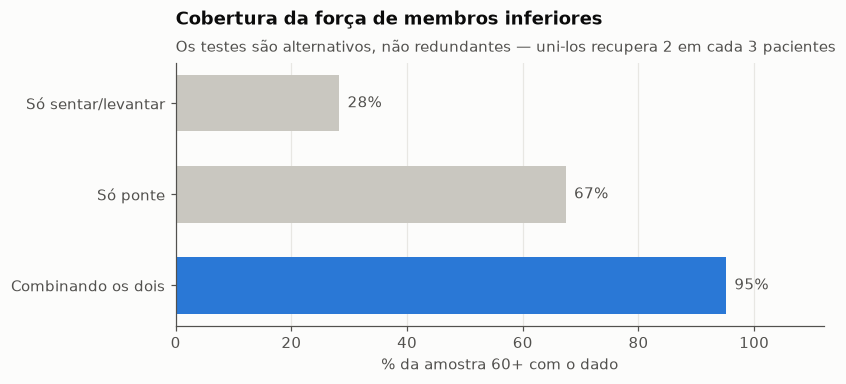

In [28]:
fig, ax = plt.subplots(figsize=(7.6, 3.1))
etapas = ["Só sentar/levantar", "Só ponte", "Combinando os dois"]
valores = [base_mais["sentar_levantar"].notna().mean() * 100,
           base_mais["ponte"].notna().mean() * 100,
           base_mais["tem_forca_mmii"].mean() * 100]
# Emphasis: o resultado é o terceiro; os dois primeiros são contexto.
cores = [CINZA, CINZA, AZUL]
barras = ax.barh(etapas[::-1], valores[::-1], color=cores[::-1], height=0.62)
for b, v in zip(barras, valores[::-1]):
    ax.text(b.get_width() + 1.4, b.get_y() + b.get_height() / 2, f"{v:.0f}%",
            va="center", fontsize=10, color=TINTA2)
rotule(ax, "Cobertura da força de membros inferiores",
       "Os testes são alternativos, não redundantes — uni-los recupera 2 em cada 3 pacientes",
       xlab="% da amostra 60+ com o dado")
so_x(ax)
ax.set_xlim(0, 112)
plt.show()

**O que aprendemos na seção 6.** Três vazios diferentes, três tratamentos. Tratar
tudo como `NaN` e imputar a média produziria uma base pior que a original: perna
amputada com 35 cm de panturrilha, e 2 em cada 3 pacientes descartados por uma
lacuna que não existia.

---
## 7. Quantos pacientes caem?

Com a base tipada, finalmente a pergunta que a AACD fez primeiro.

In [29]:
def painel_quedas(df, rotulo):
    com = df[df["n_quedas"].notna()]
    return {
        "grupo": rotulo,
        "pacientes": len(df),
        "com desfecho": len(com),
        "caiu ≥1×": int(com["caiu"].sum()),
        "taxa de queda": f"{com['caiu'].mean()*100:.1f}%",
        "caiu ≥2×": int(com["queda_recorrente"].sum()),
        "taxa recorrente": f"{com['queda_recorrente'].mean()*100:.1f}%",
        "caiu no último mês": f"{com['queda_ultimo_mes'].mean()*100:.1f}%",
    }

pd.DataFrame([painel_quedas(base_mais, "60+ (foco)"),
              painel_quedas(base_menos, "60− (comparação)")]).set_index("grupo")

,pacientes,com desfecho,caiu ≥1×,taxa de queda,caiu ≥2×,taxa recorrente,caiu no último mês
grupo,,,,,,,
60+ (foco),166,161,88,54.7%,51,31.7%,23.0%
60− (comparação),116,114,59,51.8%,28,24.6%,9.7%


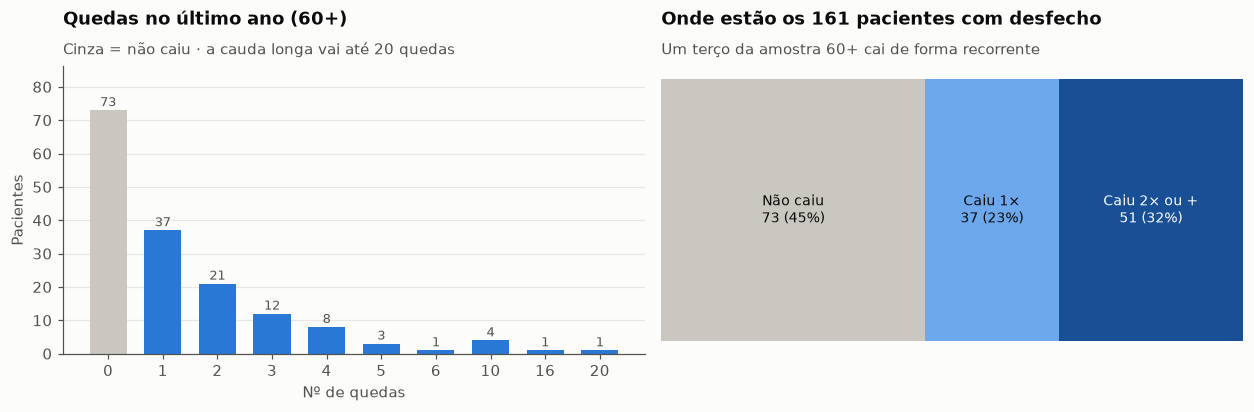

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))

# (a) distribuição do nº de quedas
dist = base_mais["n_quedas"].dropna().astype(int).value_counts().sort_index()
ax = axes[0]
cores = [CINZA if k == 0 else AZUL for k in dist.index]
barras = ax.bar(dist.index.astype(str), dist.values, color=cores, width=0.68)
for b, v in zip(barras, dist.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.2, str(v),
            ha="center", fontsize=8.5, color=TINTA2)
rotule(ax, "Quedas no último ano (60+)",
       "Cinza = não caiu · a cauda longa vai até 20 quedas",
       xlab="Nº de quedas", ylab="Pacientes")
so_y(ax)
ax.set_ylim(0, dist.max() * 1.18)

# (b) desfecho binário
ax = axes[1]
com = base_mais[base_mais["n_quedas"].notna()]
fatias = [(~com["caiu"]).sum(), (com["n_quedas"] == 1).sum(),
          (com["n_quedas"] >= 2).sum()]
etiquetas = ["Não caiu", "Caiu 1×", "Caiu 2× ou +"]
cores2 = [CINZA, AZUIS[2], AZUIS[5]]
esq = 0
for v, et, cor in zip(fatias, etiquetas, cores2):
    ax.barh([0], [v], left=esq, color=cor, height=0.5)
    ax.text(esq + v / 2, 0, f"{et}\n{v} ({v/len(com)*100:.0f}%)",
            ha="center", va="center", fontsize=9,
            color="white" if cor == AZUIS[5] else TINTA)
    esq += v
rotule(ax, "Onde estão os 161 pacientes com desfecho",
       "Um terço da amostra 60+ cai de forma recorrente")
ax.set_yticks([])
ax.grid(False)
ax.set_xlim(0, len(com))
for lado in ("left", "bottom"):
    ax.spines[lado].set_visible(False)
ax.set_xticks([])
plt.tight_layout()
plt.show()

**54,7% dos idosos caíram** no último ano e **31,7% caíram duas vezes ou mais**.

Para modelagem isso é excelente: classes equilibradas, sem necessidade de
reamostragem. E define o **piso de comparação**: um modelo que chute sempre "caiu"
acerta 54,7%. É contra esse número que qualquer modelo tem de provar valor — não
contra zero.

---
## 8. Existe um perfil de quem cai?

Primeiro cruzamento óbvio: quem se locomove pior cai mais, certo?

In [31]:
def taxa_por(df, coluna, minimo=5):
    g = df[df["n_quedas"].notna()].groupby(coluna, observed=True)["caiu"]
    out = pd.DataFrame({"pacientes": g.size(), "caíram": g.sum()})
    out["taxa de queda"] = (out["caíram"] / out["pacientes"] * 100).round(1)
    return out[out["pacientes"] >= minimo].sort_values("taxa de queda", ascending=False)

taxa_por(base_mais, "perfil_mobilidade")

,pacientes,caíram,taxa de queda
perfil_mobilidade,,,
anda,100,61,61.0
só cadeira de rodas,42,16,38.1
misto (anda e usa cadeira),6,2,33.3


O resultado é o **oposto** do esperado.

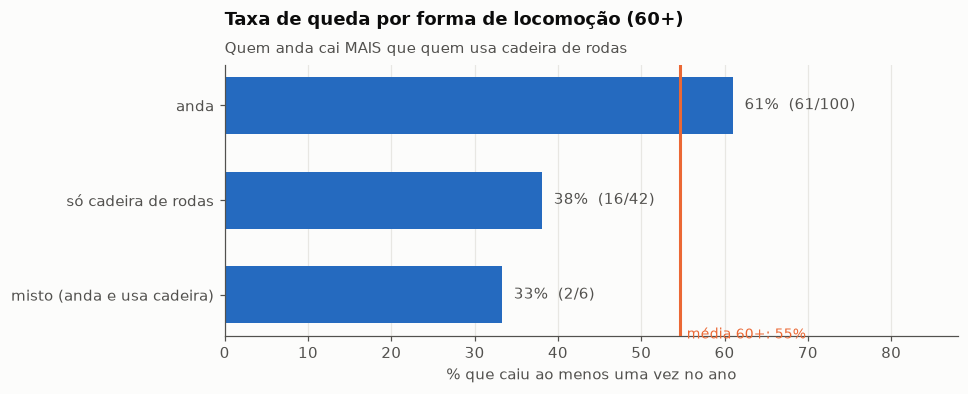

In [32]:
dados = taxa_por(base_mais, "perfil_mobilidade").sort_values("taxa de queda")
fig, ax = plt.subplots(figsize=(8.6, 3.2))
barras = ax.barh(dados.index, dados["taxa de queda"], color=AZUIS[4], height=0.6)
for b, (rot, linha) in zip(barras, dados.iterrows()):
    ax.text(b.get_width() + 1.4, b.get_y() + b.get_height() / 2,
            f"{linha['taxa de queda']:.0f}%  ({int(linha['caíram'])}/{int(linha['pacientes'])})",
            va="center", fontsize=9.5, color=TINTA2)
media = base_mais[base_mais['n_quedas'].notna()]["caiu"].mean() * 100
ax.axvline(media, color=LARANJA, linewidth=2, zorder=3)
ax.text(media + 0.8, -0.46, f"média 60+: {media:.0f}%", color=LARANJA, fontsize=9)
rotule(ax, "Taxa de queda por forma de locomoção (60+)",
       "Quem anda cai MAIS que quem usa cadeira de rodas",
       xlab="% que caiu ao menos uma vez no ano")
so_x(ax)
ax.set_xlim(0, 88)
plt.show()

In [33]:
# Teste formal: anda (inclui misto) vs só cadeira de rodas.
com = base_mais[base_mais["n_quedas"].notna()].copy()
com["anda"] = com["perfil_mobilidade"].isin(["anda", "misto (anda e usa cadeira)"])
tabela = pd.crosstab(com["anda"], com["caiu"])
odds, p = stats.fisher_exact(tabela.values)
print(tabela.to_string(), f"\n\nOdds ratio = {odds:.2f}   p = {p:.4f} (Fisher exato)")

caiu   False  True 
anda               
False     30     25
True      43     63 

Odds ratio = 1.76   p = 0.0982 (Fisher exato)


### Por que isso acontece — e por que muda o estudo inteiro

Não é erro de dado. É **exposição**: para cair andando, é preciso andar. O paciente
mais comprometido, que se locomove em cadeira de rodas, está protegido do desfecho
justamente pela gravidade.

A consequência vale para o projeto todo: **misturar cadeirantes e deambuladores
cancela o efeito de todos os testes físicos.** Os testes medem comprometimento; o
desfecho exige exposição; e os dois apontam em direções opostas.

Isso explica o resultado da próxima seção, que de outra forma pareceria um fracasso.

---
## 9. Quais testes discriminam — e quais só dão trabalho?

Vamos comparar quem caiu com quem não caiu em **toda** a amostra 60+, teste por
teste.

In [34]:
CONTINUAS = ["idade", "dinamometro", "ponte", "sentar_levantar", "reacao",
             "reacao_dt", "panturrilha_d", "tempo_10m", "moca", "dez_cs",
             "velocidade_marcha", "custo_dupla_tarefa", "cif_equilibrio"]

ROTULOS = {
    "idade": "Idade", "dinamometro": "Dinamômetro (preensão)",
    "ponte": "Ponte", "sentar_levantar": "Sentar/levantar 30 s",
    "reacao": "Reação BlazePod", "reacao_dt": "Reação BlazePod (dupla tarefa)",
    "panturrilha_d": "Panturrilha D", "tempo_10m": "Tempo 10 m",
    "moca": "MoCA", "dez_cs": "10-CS", "velocidade_marcha": "Velocidade de marcha",
    "custo_dupla_tarefa": "Custo de dupla tarefa", "cif_equilibrio": "CIF equilíbrio",
}


def compara(df, desfecho="caiu", colunas=CONTINUAS):
    '''Mann-Whitney entre quem tem e quem não tem o desfecho, coluna por coluna.'''
    linhas = []
    for col in colunas:
        sub = df[df[desfecho].notna() & df[col].notna()]
        a = sub.loc[sub[desfecho] == True, col].astype(float)
        b = sub.loc[sub[desfecho] == False, col].astype(float)
        if len(a) < 5 or len(b) < 5:
            continue
        p = stats.mannwhitneyu(a, b, alternative="two-sided").pvalue
        linhas.append({
            "variável": ROTULOS.get(col, col),
            "n com desfecho": len(a), "mediana com": round(a.median(), 2),
            "n sem desfecho": len(b), "mediana sem": round(b.median(), 2),
            "p": round(p, 4),
        })
    return pd.DataFrame(linhas).sort_values("p").reset_index(drop=True)


geral = compara(base_mais, "caiu")
geral

,variável,n com desfecho,mediana com,n sem desfecho,mediana sem,p
0,Custo de dupla tarefa,85,36.10,72,28.10,0.2209
1,Ponte,64,16.00,48,16.50,0.2505
2,10-CS,31,9.00,31,8.00,0.3487
3,Sentar/levantar 30 s,24,7.00,22,7.00,0.3688
4,Panturrilha D,50,35.00,44,35.75,0.3889
5,MoCA,35,22.00,36,19.00,0.3901
6,Tempo 10 m,75,27.00,55,27.00,0.5652
7,Dinamômetro (preensão),86,25.00,73,26.00,0.6330
8,Idade,88,68.00,73,67.00,0.7557
9,Reação BlazePod,88,31.00,73,32.00,0.7727


**Nenhum p abaixo de 0,05.** Nem força de preensão, nem velocidade de marcha, nem
cognição, nem dupla tarefa.

Lido sem cuidado, isso vira "os testes não servem" — e essa conclusão estaria
errada. O que a seção 8 mostrou é que o efeito está sendo **cancelado** pela mistura
de cadeirantes e deambuladores.

Vamos repetir a análise só entre quem anda, e testando também o desfecho de **queda
recorrente**, que é o que a literatura de prevenção costuma usar.

In [35]:
anda = base_mais[base_mais["perfil_mobilidade"].isin(
    ["anda", "misto (anda e usa cadeira)"])].copy()
print(f"Subgrupo que anda: {len(anda)} pacientes de {len(base_mais)}")

recorrente = compara(anda, "queda_recorrente")
recorrente

Subgrupo que anda: 107 pacientes de 166


,variável,n com desfecho,mediana com,n sem desfecho,mediana sem,p
0,Sentar/levantar 30 s,11,4.00,28,7.00,0.0225
1,Dinamômetro (preensão),38,22.00,66,28.00,0.0356
2,Ponte,28,16.00,40,18.50,0.0391
3,CIF equilíbrio,39,0.00,67,0.00,0.1757
4,Panturrilha D,25,35.00,40,36.00,0.1922
5,MoCA,15,22.00,32,22.00,0.2416
6,10-CS,12,9.00,28,8.00,0.3091
7,Custo de dupla tarefa,37,32.30,67,30.60,0.3349
8,Velocidade de marcha,37,0.31,66,0.39,0.3480
9,Tempo 10 m,37,32.00,66,25.50,0.3480


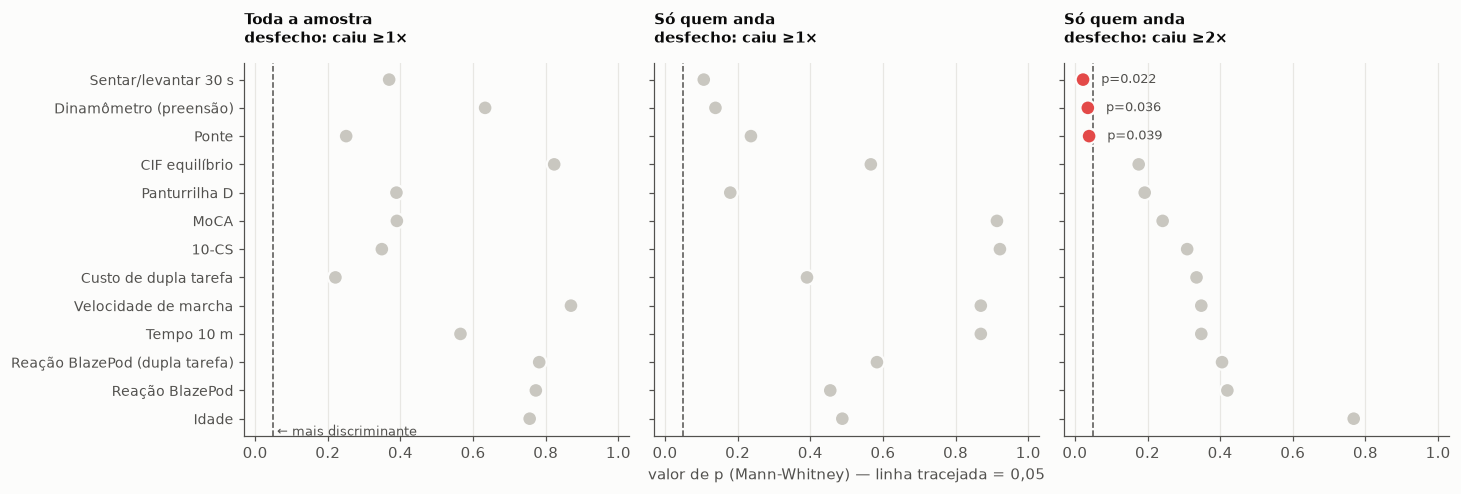

In [36]:
cenarios = {
    "Toda a amostra\ndesfecho: caiu ≥1×": compara(base_mais, "caiu"),
    "Só quem anda\ndesfecho: caiu ≥1×": compara(anda, "caiu"),
    "Só quem anda\ndesfecho: caiu ≥2×": compara(anda, "queda_recorrente"),
}

fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.6), sharex=True)
ordem = compara(anda, "queda_recorrente")["variável"].tolist()
for ax, (titulo, tab) in zip(axes, cenarios.items()):
    tab = tab.set_index("variável").reindex(ordem).dropna(subset=["p"])
    cores = [VERMELHO if p < 0.05 else (AMARELO if p < 0.10 else CINZA)
             for p in tab["p"]]
    ax.scatter(tab["p"], range(len(tab)), s=95, color=cores, zorder=3,
               edgecolor=SUPERFICIE, linewidth=1.5)
    ax.set_yticks(range(len(tab)))
    ax.set_yticklabels(tab.index if ax is axes[0] else [], fontsize=9)
    ax.axvline(0.05, color=TINTA2, linestyle="--", linewidth=1)
    ax.set_xlim(-0.03, 1.03)
    ax.invert_yaxis()
    so_x(ax)
    ax.text(0, 1.04, titulo, transform=ax.transAxes, fontsize=10,
            fontweight="bold", color=TINTA, va="bottom")
    for p, y in zip(tab["p"], range(len(tab))):
        if p < 0.10:
            ax.text(p + 0.05, y, f"p={p:.3f}", va="center", fontsize=8.5, color=TINTA2)
axes[1].set_xlabel("valor de p (Mann-Whitney) — linha tracejada = 0,05")
axes[0].text(0.06, len(ordem) - 0.4, "← mais discriminante", fontsize=8.5, color=TINTA2)
plt.tight_layout()
plt.show()

O painel conta a história inteira. Da esquerda para a direita, os mesmos testes, nas
mesmas pessoas — muda só o recorte e o desfecho:

- **Toda a amostra, caiu ≥1×**: tudo cinza. Nada discrimina.
- **Só quem anda, caiu ≥1×**: começa a aparecer sinal.
- **Só quem anda, caiu ≥2×**: **sentar/levantar 30 s discrimina** (p ≈ 0,02), com
  ponte e dinamômetro logo atrás.

Mediana de 4 repetições em quem cai de forma recorrente contra 7 em quem não cai. É
um resultado clinicamente coerente: força de membros inferiores é o que sustenta a
recuperação de um desequilíbrio.

E nas variáveis categóricas:

In [37]:
def compara_cat(df, coluna, desfecho, rotulo):
    sub = df[df[desfecho].notna() & df[coluna].notna()]
    if sub[coluna].nunique() != 2:
        return None
    tab = pd.crosstab(sub[coluna], sub[desfecho])
    if tab.shape != (2, 2):
        return None
    odds, p = stats.fisher_exact(tab.values)
    taxas = sub.groupby(coluna, observed=True)[desfecho].agg(["mean", "size"])
    return {
        "variável": rotulo,
        "grupo A": f"{taxas.index[0]}: {taxas['mean'].iloc[0]*100:.0f}% (n={taxas['size'].iloc[0]})",
        "grupo B": f"{taxas.index[1]}: {taxas['mean'].iloc[1]*100:.0f}% (n={taxas['size'].iloc[1]})",
        "odds ratio": round(odds, 2), "p": round(p, 4),
    }


anda = anda.copy()
anda["usa_dispositivo"] = anda["aditamento_grupo"].apply(
    lambda v: None if v is None or pd.isna(v) else ("nenhum" if v == "nenhum" else "usa dispositivo"))
anda["forca_preensao"] = anda.apply(
    lambda r: None if pd.isna(r["dinamometro"]) or pd.isna(r["sexo"])
    else ("abaixo do corte"
          if r["dinamometro"] < nz.CORTE_SARCOPENIA_EWGSOP2[r["sexo"]] else "no corte"),
    axis=1)
anda["marcha_lenta"] = anda["velocidade_marcha"].apply(
    lambda v: None if pd.isna(v) else ("< 0,8 m/s" if v < 0.8 else "≥ 0,8 m/s"))

testes_cat = [
    ("polifarmacia", "Polifarmácia (5+ remédios)"),
    ("sexo", "Sexo"),
    ("usa_dispositivo", "Usa dispositivo de marcha"),
    ("forca_preensao", "Força de preensão vs corte"),
    ("marcha_lenta", "Marcha lenta (corte 0,8 m/s)"),
    ("supervisao", "Precisa de supervisão"),
]
resultados = [r for col, rot in testes_cat
              for r in [compara_cat(anda, col, "caiu", rot)] if r]
pd.DataFrame(resultados).sort_values("p").reset_index(drop=True)

,variável,grupo A,grupo B,odds ratio,p
0,Polifarmácia (5+ remédios),False: 44% (n=36),True: 68% (n=63),2.69,0.0325
1,Usa dispositivo de marcha,nenhum: 41% (n=17),usa dispositivo: 63% (n=82),2.48,0.1078
2,"Marcha lenta (corte 0,8 m/s)","< 0,8 m/s: 62% (n=80)","≥ 0,8 m/s: 48% (n=23)",0.55,0.2348
3,Força de preensão vs corte,abaixo do corte: 66% (n=29),no corte: 56% (n=75),0.67,0.5059
4,Sexo,F: 63% (n=35),M: 58% (n=71),0.81,0.6773


**Polifarmácia discrimina** entre quem anda: 70% de quedas em quem toma 5 ou mais
remédios, contra 46% em quem não toma (p ≈ 0,03). É o achado mais acionável da base
— e o mais fácil de agir, porque revisão de medicação é intervenção conhecida.

> **Ressalva honesta.** `sentar_levantar` tem só 39 pacientes no subgrupo que anda.
> O p de 0,02 é real, mas frágil: é pista a confirmar na próxima coleta, não achado
> fechado. E testamos muitas variáveis — com 13 testes, um p abaixo de 0,05 por azar
> é esperado. Estes dois resultados são coerentes com a literatura, o que ajuda, mas
> não substitui replicação.

---
## 10. Os valores de referência da literatura servem aqui?

O repositório traz quatro referências com pontos de corte prontos:

| Referência | Instrumento | Corte |
|---|---|---|
| World Falls Guidelines 2022 | velocidade de marcha | < 0,8 m/s = risco |
| EWGSOP2 (2019), citado na ref. 2 | preensão manual | < 27 kg ♂ / < 16 kg ♀ |
| Nasreddine et al. (MoCA) | cognição | < 26 |
| Apolinario et al. (10-CS) | cognição | ≤ 5 provável déficit |

Vamos aplicá-los.

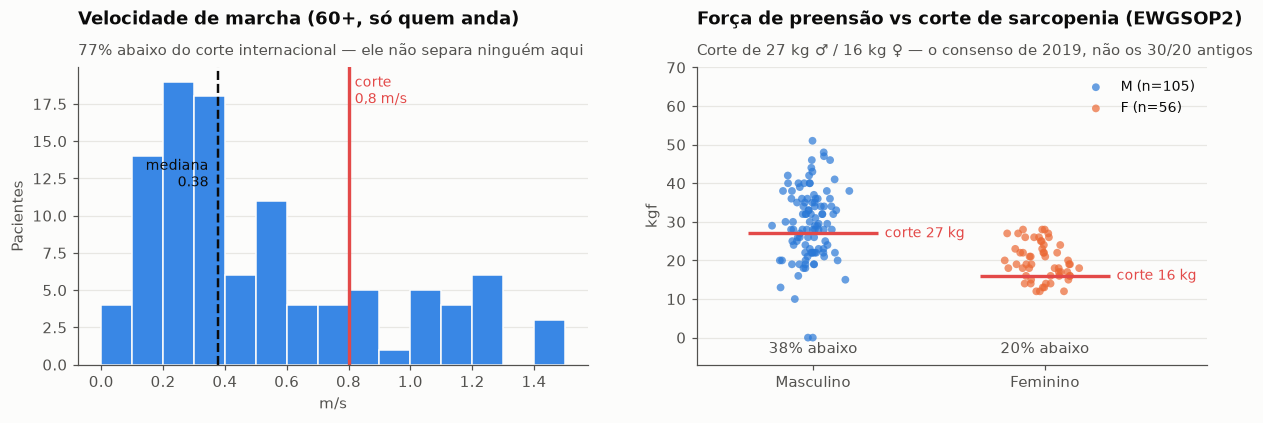

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) velocidade de marcha vs corte de 0,8 m/s
ax = axes[0]
vel = base_mais["velocidade_marcha"].dropna().astype(float)
ax.hist(vel, bins=np.arange(0, 1.6, 0.1), color=AZUIS[3], edgecolor=SUPERFICIE)
ax.axvline(0.8, color=VERMELHO, linewidth=2.2)
ax.text(0.82, ax.get_ylim()[1] * 0.88, "corte\n0,8 m/s", color=VERMELHO, fontsize=9)
ax.axvline(vel.median(), color=TINTA, linewidth=1.6, linestyle="--")
ax.text(vel.median() - 0.03, ax.get_ylim()[1] * 0.60,
        f"mediana\n{vel.median():.2f}", color=TINTA, fontsize=9, ha="right")
abaixo = (vel < 0.8).mean() * 100
rotule(ax, "Velocidade de marcha (60+, só quem anda)",
       f"{abaixo:.0f}% abaixo do corte internacional — ele não separa ninguém aqui",
       xlab="m/s", ylab="Pacientes")
so_y(ax)

# (b) preensão manual por sexo vs corte
ax = axes[1]
# EWGSOP2 (2019): 27 kg homens, 16 kg mulheres. Os valores 30/20, que aparecem na
# referência 2, são do consenso ANTERIOR (EWGSOP1) e inflam a prevalência.
for i, (sx, cor) in enumerate([("M", AZUL), ("F", LARANJA)]):
    corte = nz.CORTE_SARCOPENIA_EWGSOP2[sx]
    d = base_mais.loc[base_mais["sexo"] == sx, "dinamometro"].dropna().astype(float)
    x = np.random.default_rng(7 + i).normal(i, 0.07, len(d))
    ax.scatter(x, d, s=26, color=cor, alpha=0.7, edgecolor="none",
               label=f"{sx} (n={len(d)})")
    ax.hlines(corte, i - 0.28, i + 0.28, color=VERMELHO, linewidth=2.2)
    ax.text(i + 0.31, corte, f"corte {corte:.0f} kg", color=VERMELHO, fontsize=9, va="center")
    ax.text(i, -4, f"{(d < corte).mean()*100:.0f}% abaixo", ha="center",
            fontsize=9.5, color=TINTA2)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Masculino", "Feminino"])
ax.set_xlim(-0.5, 1.7); ax.set_ylim(-7, 70)
rotule(ax, "Força de preensão vs corte de sarcopenia (EWGSOP2)",
       "Corte de 27 kg ♂ / 16 kg ♀ — o consenso de 2019, não os 30/20 antigos",
       ylab="kgf")
so_y(ax)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

In [39]:
def satura(serie, condicao, rotulo, referencia):
    s = serie.dropna().astype(float)
    return {"indicador": rotulo, "referência": referencia,
            "n medido": len(s),
            "% além do corte": f"{condicao(s).mean()*100:.1f}%"}

vel = base_mais["velocidade_marcha"]
pd.DataFrame([
    satura(vel, lambda s: s < 0.8, "Velocidade < 0,8 m/s", "World Guidelines 2022"),
    satura(base_mais["moca"], lambda s: s < 26, "MoCA < 26", "Nasreddine 2005"),
    satura(base_mais["dez_cs"], lambda s: s <= 5, "10-CS ≤ 5", "Apolinario 2015"),
    satura(base_mais["dez_cs"], lambda s: s <= 7, "10-CS ≤ 7 (possível déficit)", "Apolinario 2015"),
]).set_index("indicador")

,referência,n medido,% além do corte
indicador,,,
"Velocidade < 0,8 m/s",World Guidelines 2022,104,76.9%
MoCA < 26,Nasreddine 2005,75,86.7%
10-CS ≤ 5,Apolinario 2015,65,9.2%
10-CS ≤ 7 (possível déficit),Apolinario 2015,65,35.4%


**Os cortes saturam.** 75% abaixo em velocidade, 87% abaixo no MoCA. Um corte que
classifica três de cada quatro pacientes como "de risco" **não prioriza ninguém** —
e priorizar era exatamente o pedido da AACD.

Isso não invalida as referências. É um resultado em si, e dos mais úteis: **a
população atendida pela AACD está fora da faixa em que os cortes internacionais
funcionam.** Eles foram construídos em idosos da comunidade, não em pessoas com
amputação, sequela de AVC ou lesão medular.

O 10-CS é a exceção — distribui os pacientes em faixas de tamanho utilizável.

A saída é um corte **próprio do serviço**, calculado na distribuição da própria
população:

In [40]:
tercis = base_mais["velocidade_marcha"].dropna().astype(float).quantile([1/3, 2/3])
print("Tercis de velocidade de marcha na população da AACD (60+):")
print(f"  tercil inferior (mais lento): < {tercis.iloc[0]:.2f} m/s")
print(f"  tercil intermediário       : {tercis.iloc[0]:.2f} – {tercis.iloc[1]:.2f} m/s")
print(f"  tercil superior (mais rápido): > {tercis.iloc[1]:.2f} m/s")
print(f"\nCorte internacional, para comparação: 0,80 m/s")
print("-> Um corte interno separa a população em grupos utilizáveis; o de 0,8 não.")

Tercis de velocidade de marcha na população da AACD (60+):
  tercil inferior (mais lento): < 0.29 m/s
  tercil intermediário       : 0.29 – 0.58 m/s
  tercil superior (mais rápido): > 0.58 m/s

Corte internacional, para comparação: 0,80 m/s
-> Um corte interno separa a população em grupos utilizáveis; o de 0,8 não.


---
## 11. Dá para transformar isso em indicadores?

**Sim — e em três famílias diferentes**, que servem a propósitos distintos. Esta é a
ponte entre a análise e o que a AACD leva para o dia a dia.

| Família | Para que serve | Quem usa |
|---|---|---|
| **1. Desfecho** | medir o problema e acompanhar ao longo do tempo | coordenação |
| **2. Fatores** | dizer onde intervir | equipe de fisioterapia |
| **3. Qualidade do dado** | melhorar a próxima coleta | quem organiza o evento |

E, acima delas, um **indicador composto** — o escore de alerta que responde
literalmente à pergunta "quem precisa de atenção primeiro?".

In [41]:
def painel(df, rotulo):
    '''Indicadores agregados. Nada aqui identifica paciente.'''
    com = df[df["n_quedas"].notna()]
    anda_ = df[df["perfil_mobilidade"].isin(["anda", "misto (anda e usa cadeira)"])]
    vel = df["velocidade_marcha"].dropna().astype(float)
    baixa = df.apply(
        lambda r: (pd.NA if pd.isna(r["dinamometro"]) or pd.isna(r["sexo"])
                   else r["dinamometro"] < nz.CORTE_SARCOPENIA_EWGSOP2[r["sexo"]]),
        axis=1).dropna()

    return pd.Series({
        # --- família 1: desfecho ---
        "Taxa de queda no ano (%)": round(com["caiu"].mean() * 100, 1),
        "Taxa de queda recorrente (%)": round(com["queda_recorrente"].mean() * 100, 1),
        "Taxa de queda no último mês (%)": round(com["queda_ultimo_mes"].mean() * 100, 1),
        "Quedas por paciente que caiu (mediana)": com.loc[com["caiu"] == True, "n_quedas"].median(),
        # --- família 2: fatores ---
        "Polifarmácia (%)": round(df["polifarmacia"].mean() * 100, 1),
        "Deambuladores (%)": round(anda_.shape[0] / len(df) * 100, 1),
        "Usa dispositivo de marcha (%)": round(
            (df["aditamento_grupo"].notna() & (df["aditamento_grupo"] != "nenhum")).mean() * 100, 1),
        "Velocidade de marcha (mediana, m/s)": round(vel.median(), 2),
        "Preensão abaixo do corte (%)": round(baixa.mean() * 100, 1),
        "Custo de dupla tarefa (mediana, %)": round(
            df["custo_dupla_tarefa"].dropna().astype(float).median(), 1),
        # --- família 3: qualidade do dado ---
        "Desfecho registrado (%)": round(df["n_quedas"].notna().mean() * 100, 1),
        "Força de MMII avaliada (%)": round(df["tem_forca_mmii"].mean() * 100, 1),
        "Completude média das colunas (%)": round(
            (1 - df[[c for c in df.columns
                     if not re.search("motivo_ausencia|reinterpretado", c)]]
             .isna().mean().mean()) * 100, 1),
    }, name=rotulo)


indicadores = pd.concat([painel(base_mais, "60+ (foco)"),
                         painel(base_menos, "60− (comparação)")], axis=1)
indicadores

,60+ (foco),60− (comparação)
Taxa de queda no ano (%),54.70,51.80
Taxa de queda recorrente (%),31.70,24.60
Taxa de queda no último mês (%),23.00,9.70
Quedas por paciente que caiu (mediana),2.00,1.00
Polifarmácia (%),66.70,41.00
Deambuladores (%),64.50,78.40
Usa dispositivo de marcha (%),63.30,67.20
"Velocidade de marcha (mediana, m/s)",0.38,0.83
Preensão abaixo do corte (%),31.70,22.40
"Custo de dupla tarefa (mediana, %)",30.60,28.50


Esse painel é o que cabe num banner: números agregados, sem paciente identificável,
e comparável entre as duas faixas de idade. Rodado de novo na coleta do ano que vem,
vira série histórica.

### O indicador composto: Índice de Alerta de Queda (IAQ)

Agora o que a AACD pediu de fato. O escore usa **só o que sobreviveu à análise** e
só variáveis que um fisioterapeuta consegue checar sem computador:

| Critério | Ponto | Por quê |
|---|---|---|
| Anda (não é exclusivamente cadeirante) | +1 | exposição — seção 8 |
| Toma 5 ou mais remédios | +1 | p ≈ 0,03 — seção 9 |
| Usa dispositivo de marcha | +1 | p ≈ 0,10 — seção 9 |
| Força de MMII baixa | +1 | p ≈ 0,02 em queda recorrente — seção 9 |

Deliberadamente **não** entram velocidade de marcha nem MoCA: a seção 10 mostrou que
saturam nesta população. Um critério que 87% da amostra cumpre não prioriza ninguém.

In [42]:
# Corte de força baixa: mediana observada em cada protocolo, calculada na própria
# população (não importada), como discutido na seção 10.
CORTE_SL = base_mais["sentar_levantar"].dropna().astype(float).median()
CORTE_PONTE = base_mais["ponte"].dropna().astype(float).median()
print(f"Cortes internos de força — sentar/levantar: < {CORTE_SL:.0f} rep · "
      f"ponte: < {CORTE_PONTE:.0f} s")


def forca_baixa(linha):
    '''Usa o teste que foi aplicado. NA quando nenhum dos dois existe.'''
    if pd.notna(linha["sentar_levantar"]):
        return float(linha["sentar_levantar"]) < CORTE_SL
    if pd.notna(linha["ponte"]):
        return float(linha["ponte"]) < CORTE_PONTE
    return pd.NA


def calcula_iaq(df):
    d = df.copy()
    d["c_anda"] = d["perfil_mobilidade"].isin(["anda", "misto (anda e usa cadeira)"])
    d["c_polifarmacia"] = d["polifarmacia"].fillna(False).astype(bool)
    d["c_dispositivo"] = (d["aditamento_grupo"].notna()
                          & (d["aditamento_grupo"] != "nenhum"))
    d["c_forca"] = d.apply(forca_baixa, axis=1).fillna(False).astype(bool)
    d["IAQ"] = (d[["c_anda", "c_polifarmacia", "c_dispositivo", "c_forca"]]
                .sum(axis=1).astype(int))
    return d


iaq = calcula_iaq(base_mais)
calib = (iaq[iaq["n_quedas"].notna()]
         .groupby("IAQ")
         .agg(pacientes=("caiu", "size"), caíram=("caiu", "sum"),
              recorrentes=("queda_recorrente", "sum")))
calib["taxa de queda (%)"] = (calib["caíram"] / calib["pacientes"] * 100).round(1)
calib["taxa recorrente (%)"] = (calib["recorrentes"] / calib["pacientes"] * 100).round(1)
calib

Cortes internos de força — sentar/levantar: < 7 rep · ponte: < 16 s


,pacientes,caíram,recorrentes,taxa de queda (%),taxa recorrente (%)
IAQ,,,,,
0,9,3,1,33.3,11.1
1,28,12,5,42.9,17.9
2,51,23,12,45.1,23.5
3,52,34,21,65.4,40.4
4,21,16,12,76.2,57.1


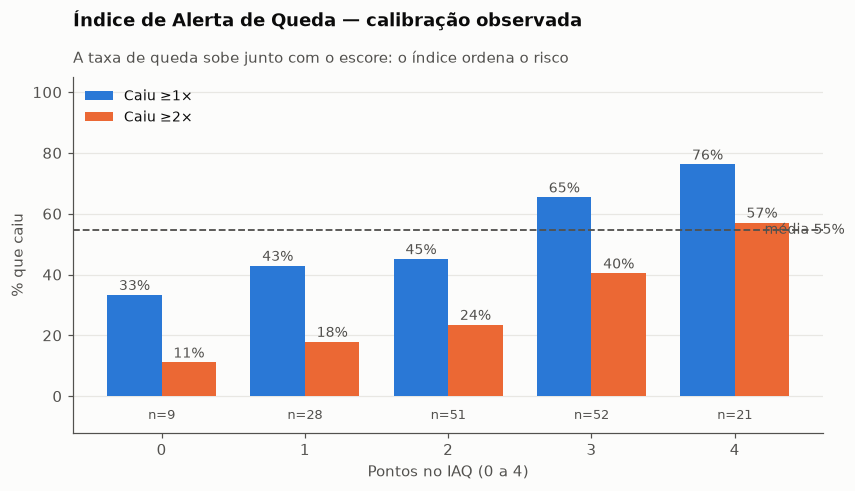

In [43]:
fig, ax = plt.subplots(figsize=(8.8, 4.2))
x = calib.index.astype(int)
larg = 0.38
b1 = ax.bar(x - larg/2, calib["taxa de queda (%)"], larg, color=AZUL, label="Caiu ≥1×")
b2 = ax.bar(x + larg/2, calib["taxa recorrente (%)"], larg, color=LARANJA,
            label="Caiu ≥2×")
for barras in (b1, b2):
    for b in barras:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.6,
                f"{b.get_height():.0f}%", ha="center", fontsize=9, color=TINTA2)
for xi, n in zip(x, calib["pacientes"]):
    ax.text(xi, -7.5, f"n={n}", ha="center", fontsize=8.5, color=TINTA2)
media = iaq[iaq["n_quedas"].notna()]["caiu"].mean() * 100
ax.axhline(media, color=TINTA2, linestyle="--", linewidth=1.2)
ax.text(x.max() + 0.18, media, f" média {media:.0f}%", fontsize=9, color=TINTA2, va="center")
rotule(ax, "Índice de Alerta de Queda — calibração observada",
       "A taxa de queda sobe junto com o escore: o índice ordena o risco",
       xlab="Pontos no IAQ (0 a 4)", ylab="% que caiu")
so_y(ax)
ax.set_xticks(x); ax.set_ylim(-12, 105)
ax.legend(loc="upper left", fontsize=9)
plt.show()

O escore **ordena** o risco: a taxa de queda sobe monotonicamente com os pontos.
Isso é o que se pede de um instrumento de triagem — não acertar caso a caso, mas
colocar a fila na ordem certa.

### Quanto vale esse escore, de verdade

Aqui é onde a honestidade importa. O IAQ foi construído **olhando estes mesmos
dados**, então a calibração acima é otimista por construção. A medida honesta é
testar em pacientes que o escore não viu — validação cruzada.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

aval = iaq[iaq["n_quedas"].notna()].copy()
y = aval["caiu"].astype(int).values

# Validação repetida: 5 folds × 20 repetições. Com 161 pacientes, um split único
# deixaria ~48 no teste e o intervalo ficaria largo demais para concluir algo.
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=7)

resultados = {}

# (1) piso: chutar sempre a classe maioritária
resultados["Classe majoritária (chutar 'caiu')"] = max(y.mean(), 1 - y.mean())

# (2) o IAQ como único preditor
X_iaq = aval[["IAQ"]].values
modelo = make_pipeline(StandardScaler(), LogisticRegression())
resultados["IAQ (escore de 4 pontos)"] = cross_val_score(
    modelo, X_iaq, y, cv=cv, scoring="accuracy").mean()
auc_iaq = cross_val_score(modelo, X_iaq, y, cv=cv, scoring="roc_auc")

# (3) núcleo de variáveis com boa cobertura
nucleo = ["idade", "dinamometro", "cif_equilibrio", "reacao", "reacao_dt"]
X_nuc = aval[nucleo].astype(float).values
modelo_nuc = make_pipeline(SimpleImputer(strategy="median"),
                           StandardScaler(), LogisticRegression(max_iter=1000))
resultados["Núcleo clínico (5 variáveis)"] = cross_val_score(
    modelo_nuc, X_nuc, y, cv=cv, scoring="accuracy").mean()
auc_nuc = cross_val_score(modelo_nuc, X_nuc, y, cv=cv, scoring="roc_auc")

comp = pd.DataFrame({
    "acurácia (validação cruzada)": {k: round(v * 100, 1) for k, v in resultados.items()},
})
comp["AUC (média ± dp)"] = [
    "—",
    f"{auc_iaq.mean():.3f} ± {auc_iaq.std():.3f}",
    f"{auc_nuc.mean():.3f} ± {auc_nuc.std():.3f}",
]
comp

,acurácia (validação cruzada),AUC (média ± dp)
Classe majoritária (chutar 'caiu'),54.7,—
IAQ (escore de 4 pontos),58.9,0.643 ± 0.087
Núcleo clínico (5 variáveis),48.7,0.435 ± 0.082


Leia a tabela com cuidado, porque ela é o resultado mais importante do notebook:

- O **piso** (chutar sempre "caiu") já acerta ~55%.
- O **IAQ** fica acima do piso, com AUC em torno de 0,6 — discriminação **modesta**.
- O **núcleo clínico** com 5 variáveis não supera o escore simples de forma
  convincente.

AUC de 0,6 significa: dados dois pacientes, um que caiu e um que não, o escore põe o
que caiu na frente em cerca de 6 de cada 10 vezes. É melhor que moeda, e é pouco
para decidir sozinho.

**A conclusão honesta para a AACD:** os dados de hoje permitem **ordenar** a fila de
prevenção, não **prever** queda individual. O IAQ serve para decidir quem a equipe
chama primeiro quando há 280 pacientes e agenda para 40. Não serve para dizer a um
paciente que ele vai cair.

Um resultado modesto bem explicado vale mais para a AACD do que um número bonito e
errado — é o que o enunciado do projeto pede, e é o que os dados sustentam.

In [45]:
# Perfil de alerta em uma frase, que é o que a equipe vai usar na prática.
alto = iaq[(iaq["IAQ"] >= 3) & iaq["n_quedas"].notna()]
print("PERFIL DE ALERTA — pacientes 60+ com IAQ ≥ 3\n" + "=" * 52)
print(f"Quantos são            : {len(alto)} de {iaq['n_quedas'].notna().sum()} "
      f"({len(alto)/iaq['n_quedas'].notna().sum()*100:.0f}% da amostra)")
print(f"Destes, quantos caíram : {int(alto['caiu'].sum())} ({alto['caiu'].mean()*100:.0f}%)")
print(f"Caíram 2× ou mais      : {int(alto['queda_recorrente'].sum())} "
      f"({alto['queda_recorrente'].mean()*100:.0f}%)")
print(f"\nIdade mediana          : {alto['idade'].median():.0f} anos")
print(f"Diagnósticos mais comuns: "
      f"{', '.join(f'{k} ({v})' for k, v in alto['dx_grupo'].value_counts().head(3).items())}")
print("\n" + "-" * 52)
print("Frase para a equipe:")
print("  \"Idoso que anda, usa dispositivo de marcha, toma 5 ou mais")
print("   remédios e tem força de pernas abaixo da mediana do serviço.\"")

PERFIL DE ALERTA — pacientes 60+ com IAQ ≥ 3
Quantos são            : 73 de 161 (45% da amostra)
Destes, quantos caíram : 50 (68%)
Caíram 2× ou mais      : 33 (45%)

Idade mediana          : 67 anos
Diagnósticos mais comuns: AMP (40), LEA (17), LM (5)

----------------------------------------------------
Frase para a equipe:
  "Idoso que anda, usa dispositivo de marcha, toma 5 ou mais
   remédios e tem força de pernas abaixo da mediana do serviço."


---
## 12. Salvar o resultado

Duas saídas: a base tratada (para as próximas atividades) e a tabela de pendências
(para levar à AACD).

> A pasta `saidas/` está no `.gitignore` — ela contém dados por paciente e **não
> deve ser versionada**.

In [46]:
import os
os.makedirs("saidas", exist_ok=True)

base.to_csv("saidas/base_tratada.csv", index=False)
indicadores.to_csv("saidas/indicadores.csv")
calib.to_csv("saidas/calibracao_iaq.csv")

# Pendências: tudo que precisa de confirmação da AACD, com ID e campo.
pend = avisos.copy()
pend["duvida"] = pend["dominio"]
extra = []
for nome, df_ in [("60+", mais), ("60-", menos)]:
    for _, r in df_.iterrows():
        if pd.isna(r["Polifarmácia?"]):
            extra.append({"aba": nome, "id": r["ID"], "campo": "polifarmacia",
                          "valor": "", "duvida": "em branco — não perguntado ou não anotado?"})
        if pd.isna(r["Nº quedas ao chão"]):
            extra.append({"aba": nome, "id": r["ID"], "campo": "n_quedas",
                          "valor": "", "duvida": "desfecho ausente — paciente sai da análise"})
        if isinstance(r["Queda último mês"], (int, float)) and not pd.isna(r["Queda último mês"]):
            extra.append({"aba": nome, "id": r["ID"], "campo": "queda_ultimo_mes",
                          "valor": r["Queda último mês"],
                          "duvida": "codificado como número em vez de sim/não"})
        if str(r["Suporte social (domiciliar)"]) == "." or str(r["Suporte social (terapêutico)"]) == ".":
            extra.append({"aba": nome, "id": r["ID"], "campo": "suporte_social",
                          "valor": ".", "duvida": "'.' é sem dado ou sem acompanhante?"})
        if (re.search(r"cadeir", str(r["Aditamento 10m"]), re.I)
                and not pd.isna(r["10 metros"]) and str(r["10 metros"]) != "NA"):
            extra.append({"aba": nome, "id": r["ID"], "campo": "tempo_10m",
                          "valor": r["10 metros"],
                          "duvida": "cadeirante com tempo de 10 m: andando ou na cadeira?"})
pend = pd.concat([pend, pd.DataFrame(extra)], ignore_index=True)
pend.to_csv("saidas/pendencias.csv", index=False)

print(f"saidas/base_tratada.csv   : {base.shape[0]} pacientes × {base.shape[1]} colunas")
print(f"saidas/indicadores.csv    : {indicadores.shape[0]} indicadores × 2 grupos")
print(f"saidas/calibracao_iaq.csv : {calib.shape[0]} faixas de escore")
print(f"saidas/pendencias.csv     : {len(pend)} itens para confirmar com a AACD")
print("\nPendências por tipo:")
print(pend["duvida"].value_counts().to_string())

saidas/base_tratada.csv   : 282 pacientes × 44 colunas
saidas/indicadores.csv    : 13 indicadores × 2 grupos
saidas/calibracao_iaq.csv : 5 faixas de escore
saidas/pendencias.csv     : 86 itens para confirmar com a AACD

Pendências por tipo:
duvida
em branco — não perguntado ou não anotado?              33
cadeirante com tempo de 10 m: andando ou na cadeira?    22
codificado como número em vez de sim/não                 8
desfecho ausente — paciente sai da análise               7
valor_com_duvida                                         6
'.' é sem dado ou sem acompanhante?                      4
0–10                                                     2
duvidoso                                                 2
3–400                                                    1
15–60                                                    1


---
## Resumo: o que este notebook estabeleceu

**Sobre o tratamento**

1. Cada paciente ocupa 2 linhas — sem achatar, a análise roda em 332 fantasmas e
   perde o sexo de parte da amostra.
2. Nenhuma coluna vinha tipada; `Panturrilha D` misturava três tipos de Python.
3. Existem **três** tipos de ausência, e tratá-los igual estraga a base: imputar
   média em panturrilha de amputado inventa uma perna.
4. Ponte e sentar/levantar são **alternativos**, não redundantes — uni-los leva a
   cobertura de força de MMII de 28% para 95%.
5. A validação de domínio pegou o que a inspeção visual não pega: 10-CS acima do
   máximo do instrumento, 10 m em 1,2 s, idade digitada como `'k'`.

**Sobre os achados**

6. 54,7% dos idosos caíram; 31,7% caíram duas vezes ou mais.
7. **Quem anda cai mais que quem usa cadeira** (61% vs 39%, p = 0,015). É exposição,
   não erro — e misturar os dois grupos cancela o efeito de todos os testes.
8. Estratificando por mobilidade e usando queda recorrente, aparece sinal:
   **sentar/levantar** (p ≈ 0,02) e **polifarmácia** (p ≈ 0,03).
9. Os cortes internacionais **saturam** nesta população (75% abaixo em velocidade,
   87% no MoCA) — a AACD precisa de cortes próprios.

**Sobre os indicadores**

10. Dá para construir três famílias de indicadores mais um escore composto (IAQ).
11. O IAQ **ordena** o risco de forma consistente, com AUC ≈ 0,6 em validação
    cruzada: bom para priorizar fila, insuficiente para prever caso individual.

**O que levar para a AACD**

- Perfil de alerta: *idoso que anda, usa dispositivo, toma 5+ remédios e tem força
  de pernas abaixo da mediana do serviço*.
- Coleta: as outras **duas Perguntas-Chave** das World Guidelines ("sente-se
  inseguro?", "tem medo de cair?") custam duas perguntas e estão entre os melhores
  preditores da literatura.
- Coleta: registrar **exposição** (horas por dia em pé ou andando). Sem isso, o
  paradoxo da seção 8 se repete em toda coleta futura.
- Formulário: lista fechada nos campos categóricos, e códigos diferentes para "não
  aplicável" e "não realizado".